## 1. Imports and setup

In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.mask import mask
from rasterio.transform import rowcol
from rasterio.windows import Window
import seaborn as sns
from shapely.geometry import box, mapping
from sklearn.metrics import r2_score
import datetime
import pandas as pd

import hatfield_funcs as hf

project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root / "src"))

from biofilm_spectra.processing.micasense import *
from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix
from my_extra_to_hatfield_funcs.io_funcs import *

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

pd.set_option("display.max_columns", 120)

## 2. Azure configuration

In [2]:
STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"

if os.getenv("GA_STORAGE_ACCOUNT_NAME") is None:
    raise EnvironmentError(
        "This notebook is configured for GeoAnalytics. "
        "GA_STORAGE_ACCOUNT_NAME is not set."
    )

hf.config.configure_azure()
hf.config.configure_data_root_path(CONTAINER_NAME)

os.environ.setdefault("AZURE_STORAGE_ACCOUNT", STORAGE_ACCOUNT_NAME)
os.environ.setdefault("GDAL_AZURE_USE_MSI", "YES")
os.environ.setdefault("GDAL_CACHEMAX", "512")

sas_token = os.getenv("AZURE_STORAGE_SAS_TOKEN")
if sas_token:
    os.environ["AZURE_STORAGE_SAS_TOKEN"] = sas_token

print("Storage account:", STORAGE_ACCOUNT_NAME)
print("Container:", CONTAINER_NAME)
print("External SAS token available:", bool(sas_token))

Storage account: geoanalytics
Container: wesa-fup-restricted-027817p
External SAS token available: False


## 3. Analysis parameters

In [3]:
def container_path_to_vsiaz(path):
    path = str(path).replace("\\", "/").lstrip("/")
    return f"/vsiaz/{CONTAINER_NAME}/{path}"


def vsiaz_exists(path):
    try:
        with rasterio.open(path):
            return True
    except rasterio.errors.RasterioIOError:
        return False


In [4]:
CORRECT_IMAGERY_CRS = "EPSG:6339"


SOURCE_BANDS_11B_TO_10B = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11]

path_spectra_processed_folder = Path("data/processed/spectra")

ROUND_DATES = {
    1: "2026-05-04",
    2: "2026-05-18",
}

SITE_CONFIG = {
    "westham": {
        "label": "Westham Center",
        "station_prefix": "W",
    },
    "brunswick": {
        "label": "Brunswick",
        "station_prefix": "B",
    },
}


# MultiIndex based on sites, dates, and DLS mode
SITES = ["brunswick", "westham"]
DATES = ["2026-05-04", "2026-05-18"]
DLS_MODES = ["NoDLS", "DLS"]

df_raster_path_in_container = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [SITES, ROUND_DATES.keys(), DLS_MODES],
        names=["site", "round", "dls_mode"],
    )
)

for round_, date_ in ROUND_DATES.items():
    date_dt = datetime.datetime.strptime(date_, "%Y-%m-%d")
    date_text = date_dt.strftime("%Y%m%d")
    folder = f"airborne_data_{date_text}_v2_COG"

    for site in SITES:
        for dls_mode in DLS_MODES:
            relative_path = (
                f"{folder}/"
                f"RTB2_10Band_{site.capitalize()}_"
                f"{date_text}_{dls_mode}_v2.tif"
            )

            df_raster_path_in_container.loc[
                (site, round_, dls_mode),
                "container_path",
            ] = relative_path

            df_raster_path_in_container.loc[
                (site, round_, dls_mode),
                "vsiaz_path",
            ] = container_path_to_vsiaz(relative_path)

for idx, row in df_raster_path_in_container.iterrows():
    vsiaz_path = row["vsiaz_path"]
    if not vsiaz_exists(vsiaz_path):
        raise FileNotFoundError(f"File does not exist: {vsiaz_path}")

In [42]:
POLYGON_RELATIVE_PATHS = {
    "westham": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_westham_v2.geojson"
    ),
    "brunswick": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_brunswick_v2.geojson"
    ),
}

POLYGON_PATHS = {
    site: container_path_to_vsiaz(path) for site, path in POLYGON_RELATIVE_PATHS.items()
}

In [5]:
container_path_station_polygons = Path(
    "data/raw_clean/gnss/biofilm_2x2m_and_3x3m_quadrat_polygons.geojson"
)

container_path_spectra_processed_folder = Path("data/processed/spectra")


vsiaz_path_station_polygons = container_path_to_vsiaz(container_path_station_polygons)

In [6]:
STATIONS_TO_HIGHLIGHT = {
    # Observed May 5, after the May 4 flight.
    ("westham", 1): [
        "W24",
        "W25",
        "W26",
        "W27",
        "W28",
        "W29",
        "W30",
    ],
    ("brunswick", 1): [
        "B24",
        "B25",
        "B26",
        "B27",
        "B28",
        "B29",
        "B30",
    ],
    # Round 2 lists retained from the existing notebook.
    ("westham", 2): [
        "W24",
        "W25",
        "W26",
        "W27",
        "W28",
        "W29",
        "W30",
        "W16",
        "W17",
        "W18",
        "W19",
        "W23",
    ],
    ("brunswick", 2): [
        "B24",
        "B25",
        "B26",
        "B27",
        "B28",
        "B29",
        "B30",
        "B17",
        "B20",
        "B21",
        "B22",
        "B23",
    ],
}


# Load and normalize station polygons

In [7]:
stations = gpd.read_file(vsiaz_path_station_polygons)

stations = stations.to_crs(CORRECT_IMAGERY_CRS).copy()

stations["station_name"] = (
    stations["station_name"]
    .astype("string")
    .str.strip()
)

stations["round"] = pd.to_numeric(
    stations["round"],
    errors="raise",
).astype("Int64")

bool_mapping = {
    "true": True,
    "false": False,
    "yes": True,
    "no": False,
    "1": True,
    "0": False,
}

stations["is_3x3m"] = (
    stations["is_3x3m"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(bool_mapping)
    .astype("boolean")
)

if stations["is_3x3m"].isna().any():
    raise ValueError("Some is_3x3m values could not be converted.")

if stations.geometry.isna().any():
    raise ValueError("Some station geometries are missing.")

if (~stations.geometry.is_valid).any():
    raise ValueError("Some station geometries are invalid.")

print("Total station polygons:", len(stations))
display(stations.head())

Total station polygons: 140


,station_name,round,is_3x3m,extended_protocol,side_m,geometry
0,B24,1,False,No,2.0,"POLYGON ((490748.006 5433263.646, 490750.006 5..."
1,B27,1,False,No,2.0,"POLYGON ((489976.691 5432602.785, 489978.691 5..."
2,B30,1,False,No,2.0,"POLYGON ((489836.101 5432131.465, 489838.101 5..."
3,B29,1,False,No,2.0,"POLYGON ((489650.933 5432177.784, 489652.933 5..."
4,B28,1,False,No,2.0,"POLYGON ((489716.834 5432484.377, 489718.834 5..."


In [8]:
df_stations = stations.copy()
df_stations["site"] = df_stations["station_name"].map(
    lambda x: "brunswick" if x.startswith("B") else "westham"
)
df_stations.rename(columns={"station_name": "station_id"}, inplace=True)
df_stations.set_index(["site", "round"], inplace=True)
df_stations = df_stations[~df_stations['is_3x3m']]

print("Total station polygons:", len(df_stations))
display(df_stations.head())

Total station polygons: 120


station_id  is_3x3m extended_protocol  side_m  \
site      round                                                 
brunswick 1            B24    False                No     2.0   
          1            B27    False                No     2.0   
          1            B30    False                No     2.0   
          1            B29    False                No     2.0   
          1            B28    False                No     2.0   

                                                          geometry  
site      round                                                     
brunswick 1      POLYGON ((490748.006 5433263.646, 490750.006 5...  
          1      POLYGON ((489976.691 5432602.785, 489978.691 5...  
          1      POLYGON ((489836.101 5432131.465, 489838.101 5...  
          1      POLYGON ((489650.933 5432177.784, 489652.933 5...  
          1      POLYGON ((489716.834 5432484.377, 489718.834 5...

# Spectra extraction from imagery

In [74]:
def extract_spectra_in_polygon(
    raster_path,
    geometry,
    band_indexes,
    wavelengths_nm,
    all_touched=False,
):
    """
    Extract valid pixel spectra inside one polygon.

    The polygon geometry must use the same CRS as the raster.
    Returns one row per pixel and one column per wavelength.
    """
    band_indexes = list(band_indexes)
    wavelengths_nm = list(wavelengths_nm)

    if len(band_indexes) != len(wavelengths_nm):
        raise ValueError("The number of bands must match the number of wavelengths.")

    with rasterio.open(raster_path) as src:
        data, transform = rasterio.mask.mask(
            src,
            [mapping(geometry)],
            indexes=band_indexes,
            crop=True,
            filled=False,
            all_touched=all_touched,
        )

        # Keep pixels that are valid in every selected band.
        valid = ~np.ma.getmaskarray(data).any(axis=0) & np.isfinite(data.data).all(
            axis=0
        )

        rows, cols = np.where(valid)

        if len(rows) == 0:
            return pd.DataFrame()

        # Shape: pixels × bands
        spectra = data.data[:, valid].T.astype("float32")

        # Pixel-centre coordinates.
        xs, ys = rasterio.transform.xy(
            transform,
            rows,
            cols,
            offset="center",
        )

        xs = np.asarray(xs)
        ys = np.asarray(ys)

        # Rows and columns in the original raster.
        raster_rows, raster_cols = rowcol(
            src.transform,
            xs,
            ys,
        )

    output = pd.DataFrame(
        spectra,
        columns=wavelengths_nm,#[f"R{w}" for w in wavelengths_nm],
    )

    # output.insert(0, "y", ys)
    # output.insert(0, "x", xs)
    # output.insert(0, "raster_col", raster_cols)
    # output.insert(0, "raster_row", raster_rows)

    output.index.name = 'pixel_id'

    return output

site = 'brunswick'  # or 'westham', depending on the station
round_ = 1
dls_mode = 'NoDLS'
df_stations_this_site_and_round = df_stations.xs(
    (site, round_), level=("site", "round")
)
station = df_stations_this_site_and_round.iloc[0]

station_spectra = extract_spectra_in_polygon(
    raster_path=df_raster_path_in_container.loc[(site, round_, dls_mode), "vsiaz_path"],
    geometry=station.geometry,
    band_indexes=SOURCE_BANDS_11B_TO_10B,
    wavelengths_nm=MICASENSE_10B_CENTER_WAVELENGTHS,
)

display(station_spectra)

,444,475,531,560,650,668,705,717,740,842
pixel_id,,,,,,,,,,
0,0.090502,0.094418,0.120015,0.133701,0.138720,0.116778,0.153933,0.163384,0.161334,0.175938
1,0.093308,0.096426,0.123924,0.136023,0.144916,0.117108,0.156506,0.162570,0.162950,0.178868
2,0.092391,0.098618,0.122848,0.135660,0.146886,0.119746,0.156827,0.161501,0.165697,0.180257
3,0.088656,0.094817,0.119415,0.133203,0.143860,0.116119,0.155751,0.162379,0.163520,0.182052
4,0.086124,0.092082,0.116343,0.131179,0.139886,0.112061,0.153281,0.166184,0.165641,0.182004
5,0.083493,0.090788,0.117187,0.130541,0.138703,0.110954,0.152126,0.163272,0.166543,0.184334
6,0.091442,0.095656,0.121619,0.135969,0.142532,0.118148,0.160136,0.163824,0.163837,0.179193
7,0.092396,0.096178,0.124619,0.137116,0.144247,0.115700,0.157184,0.162152,0.162878,0.181347
8,0.091797,0.098424,0.122404,0.136679,0.145394,0.117870,0.155657,0.162537,0.165835,0.185566


In [10]:

extracted = []
for (site, round_number, dls_mode), raster_row in df_raster_path_in_container.iterrows():

    stations = df_stations.xs(
        (site, round_number),
        level=("site", "round"),
    )

    print(
        f"Extracting {site} | "
        f"round {round_number} | {dls_mode} | "
        f"{len(stations)} stations"
    )

    raster_path = raster_row["vsiaz_path"]

    for station in stations.itertuples(index=False):
        spectra = extract_spectra_in_polygon(
            raster_path=raster_path,
            geometry=station.geometry,
            band_indexes=SOURCE_BANDS_11B_TO_10B,
            wavelengths_nm=MICASENSE_10B_CENTER_WAVELENGTHS,
        )
        spectra.reset_index(inplace=True)

        if spectra.empty:
            print(f"  No valid pixels: {station.station_id}")
            continue

        # Add station and image metadata.
        spectra.insert(
            0,
            "station_id",
            station.station_id,
        )
        spectra.insert(
            0,
            "dls_mode",
            dls_mode,
        )
        spectra.insert(
            0,
            "round",
            round_number,
        )
        spectra.insert(
            0,
            "site",
            site,
        )

        # spectra["raster_path"] = raster_path

        extracted.append(spectra)


df_all_imagery_spectra = pd.concat(
    extracted,
    ignore_index=True,
)
df_all_imagery_spectra.set_index(
    ["site", "round", "dls_mode", "station_id", "pixel_id"],
    inplace=True,
)
df_all_imagery_spectra

Extracting brunswick | round 1 | NoDLS | 30 stations
Extracting brunswick | round 1 | DLS | 30 stations
Extracting brunswick | round 2 | NoDLS | 30 stations
Extracting brunswick | round 2 | DLS | 30 stations
Extracting westham | round 1 | NoDLS | 30 stations
Extracting westham | round 1 | DLS | 30 stations
Extracting westham | round 2 | NoDLS | 30 stations
Extracting westham | round 2 | DLS | 30 stations


444       475       531  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.090502  0.094418  0.120015   
                                    1         0.093308  0.096426  0.123924   
                                    2         0.092391  0.098618  0.122848   
                                    3         0.088656  0.094817  0.119415   
                                    4         0.086124  0.092082  0.116343   
...                                                ...       ...       ...   
westham   2     DLS      W4         46        0.067807  0.069281  0.081920   
                                    47        0.063814  0.068773  0.083999   
                                    48        0.060559  0.064742  0.080413   
                                    49        0.065446  0.069607  0.084282   
                                    50        0.062617  0.067748  0.082702   

                                                   560       650       668  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.133701  0.138720  0.116778   
                                    1         0.136023  0.144916  0.117108   
                                    2         0.135660  0.146886  0.119746   
                                    3         0.133203  0.143860  0.116119   
                                    4         0.131179  0.139886  0.112061   
...                                                ...       ...       ...   
westham   2     DLS      W4         46        0.089738  0.097285  0.092385   
                                    47        0.088837  0.098378  0.090991   
                                    48        0.087938  0.096528  0.093600   
                                    49        0.090318  0.098641  0.092247   
                                    50        0.088728  0.095503  0.092378   

                                                   705       717       740  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.153933  0.163384  0.161334   
                                    1         0.156506  0.162570  0.162950   
                                    2         0.156827  0.161501  0.165697   
                                    3         0.155751  0.162379  0.163520   
                                    4         0.153281  0.166184  0.165641   
...                                                ...       ...       ...   
westham   2     DLS      W4         46        0.104825  0.098696  0.101051   
                                    47        0.103897  0.099788  0.099524   
                                    48        0.100000  0.100890  0.099217   
                                    49        0.104091  0.101146  0.100386   
                                    50        0.101487  0.100040  0.099956   

                                                   842  
site      round dls_mode station_id pixel_id            
brunswick 1     NoDLS    B24        0         0.175938  
                                    1         0.178868  
                                    2         0.180257  
                                    3         0.182052  
                                    4         0.182004  
...                                                ...  
westham   2     DLS      W4         46        0.107072  
                                    47        0.108733  
                                    48        0.112704  
                                    49        0.112907  
                                    50        0.111735  

[10812 rows x 10 columns]

In [11]:
# Compute NDVI740 using bands 668 and 740 nm
df_all_imagery_spectra["NDVI740"] = (
    (df_all_imagery_spectra[740] - df_all_imagery_spectra[668])
    / (df_all_imagery_spectra[740] + df_all_imagery_spectra[668])
)
df_all_imagery_spectra.head()

444       475       531  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.090502  0.094418  0.120015   
                                    1         0.093308  0.096426  0.123924   
                                    2         0.092391  0.098618  0.122848   
                                    3         0.088656  0.094817  0.119415   
                                    4         0.086124  0.092082  0.116343   

                                                   560       650       668  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.133701  0.138720  0.116778   
                                    1         0.136023  0.144916  0.117108   
                                    2         0.135660  0.146886  0.119746   
                                    3         0.133203  0.143860  0.116119   
                                    4         0.131179  0.139886  0.112061   

                                                   705       717       740  \
site      round dls_mode station_id pixel_id                                 
brunswick 1     NoDLS    B24        0         0.153933  0.163384  0.161334   
                                    1         0.156506  0.162570  0.162950   
                                    2         0.156827  0.161501  0.165697   
                                    3         0.155751  0.162379  0.163520   
                                    4         0.153281  0.166184  0.165641   

                                                   842   NDVI740  
site      round dls_mode station_id pixel_id                      
brunswick 1     NoDLS    B24        0         0.175938  0.160209  
                                    1         0.178868  0.163687  
                                    2         0.180257  0.160984  
                                    3         0.182052  0.169508  
                                    4         0.182004  0.192938

In [12]:
df_all_imagery_spectra_stats = df_all_imagery_spectra.groupby(
    level=["site", "round", "dls_mode", "station_id"]
).agg(["mean", "std"])

df_all_imagery_spectra_stats

444                 475            \
                                         mean       std      mean       std   
site      round dls_mode station_id                                           
brunswick 1     DLS      B1          0.016985  0.001458  0.017516  0.001468   
                         B10         0.016650  0.001132  0.017125  0.001132   
                         B11         0.018238  0.000745  0.018384  0.000818   
                         B12         0.019162  0.001643  0.019251  0.001728   
                         B13         0.014660  0.001194  0.015025  0.001219   
...                                       ...       ...       ...       ...   
westham   2     NoDLS    W5          0.109656  0.009167  0.117315  0.008883   
                         W6          0.092479  0.004567  0.099065  0.004566   
                         W7          0.072482  0.002220  0.080798  0.002353   
                         W8          0.083914  0.002692  0.091581  0.002686   
                         W9          0.096440  0.002907  0.104068  0.003606   

                                          531                 560            \
                                         mean       std      mean       std   
site      round dls_mode station_id                                           
brunswick 1     DLS      B1          0.021028  0.001378  0.022332  0.001307   
                         B10         0.021316  0.001276  0.022701  0.001349   
                         B11         0.021655  0.001034  0.023106  0.001193   
                         B12         0.021945  0.001550  0.022586  0.001427   
                         B13         0.017327  0.001132  0.018132  0.001062   
...                                       ...       ...       ...       ...   
westham   2     NoDLS    W5          0.141351  0.009617  0.152057  0.009898   
                         W6          0.122907  0.005401  0.131514  0.004359   
                         W7          0.105575  0.002752  0.118455  0.002529   
                         W8          0.117928  0.003328  0.127207  0.003132   
                         W9          0.131683  0.004016  0.142255  0.003695   

                                          650                 668            \
                                         mean       std      mean       std   
site      round dls_mode station_id                                           
brunswick 1     DLS      B1          0.021839  0.001152  0.018987  0.001018   
                         B10         0.022299  0.001346  0.019090  0.000894   
                         B11         0.022416  0.001262  0.019270  0.000974   
                         B12         0.022390  0.001277  0.020167  0.001192   
                         B13         0.018027  0.001014  0.016361  0.001034   
...                                       ...       ...       ...       ...   
westham   2     NoDLS    W5          0.166069  0.008992  0.159645  0.008917   
                         W6          0.142892  0.005304  0.136947  0.003533   
                         W7          0.134510  0.002952  0.121580  0.003298   
                         W8          0.142124  0.003793  0.135764  0.002984   
                         W9          0.156070  0.004843  0.147309  0.003952   

                                          705                 717            \
                                         mean       std      mean       std   
site      round dls_mode station_id                                           
brunswick 1     DLS      B1          0.024162  0.001285  0.025021  0.001374   
                         B10         0.024525  0.001552  0.025302  0.001882   
                         B11         0.024378  0.001131  0.025278  0.001588   
                         B12         0.023923  0.001393  0.023920  0.001592   
                         B13         0.019539  0.001196  0.019599  0.001268   
...                                       ...       ...       ...       ...   
westham   

# Load Ground-Truth Spectra

In [13]:
# Spectrometers

df_reflectance_spectra_with_metadata = pd.DataFrame()
scan_cols = ["station_id", "round", "sample_type", "scan_id", "pair_id"] # Column to extract when converting the dataframe from parquet

for site in SITES:
    path_parquet = (
        path_spectra_processed_folder
        / f"{site}_reflectance_common_wavelengths_scans.parquet"
    )
    df_reflectance_spectra_with_metadata_site = read_df_from_parquet(path_parquet)
    df_reflectance_spectra_with_metadata = pd.concat(
        [
            df_reflectance_spectra_with_metadata,
            df_reflectance_spectra_with_metadata_site,
        ],
        ignore_index=True,
    )
# This dataframe contains the individual reflectance spectra for all sites
df_reflectance_spectra_with_metadata.head()

# Transform to a spectral matrix format for easier analysis, without the metadata, subset to our round of interest
df_reflectance_spectra = to_spectral_matrix(df_reflectance_spectra_with_metadata, scan_cols=scan_cols)

# # Select only 'R' sample type
# df_reflectance_spectra = df_reflectance_spectra.xs("R", level="sample_type", axis=1)

mask = df_reflectance_spectra.columns.get_level_values("sample_type").isin(["R", "O"])
df_reflectance_spectra = df_reflectance_spectra.loc[:, mask]

# # This dataframe contains the individual reflectance spectra, with wavelength as index
# and some column levels including 'station_id', 'round', and 'sample_type', common to all
df_reflectance_spectra.head()


station_id           B9                                                    \
round                 1                                                     
sample_type           R                                                     
scan_id             0         1         2         3         4         5     
pair_id               0         0         1         1         2         2   
wavelength_nm                                                               
350.0          0.028479  0.031037  0.031922  0.034082  0.022094  0.023836   
351.0          0.028399  0.030893  0.031855  0.034021  0.022230  0.023737   
352.0          0.028388  0.030864  0.031753  0.033921  0.022177  0.023623   
353.0          0.028398  0.030867  0.031672  0.033839  0.022087  0.023516   
354.0          0.028427  0.030885  0.031712  0.033873  0.022038  0.023456   

station_id                                                                 \
round                                                                       
sample_type                                                                 
scan_id             6         7         8         9         10        11    
pair_id               3         3         4         4         5         5   
wavelength_nm                                                               
350.0          0.028329  0.029286  0.031583  0.032518  0.031386  0.033041   
351.0          0.028318  0.029086  0.031295  0.032486  0.031203  0.032940   
352.0          0.028198  0.029019  0.031221  0.032427  0.031220  0.032780   
353.0          0.028110  0.028993  0.031213  0.032377  0.031268  0.032633   
354.0          0.028260  0.029005  0.031261  0.032386  0.031242  0.032598   

station_id                                                                 \
round                                                                       
sample_type                                                                 
scan_id             12        13        14        15        18        19    
pair_id               6         6         7         7         8         8   
wavelength_nm                                                               
350.0          0.033573  0.035821  0.026341  0.028897  0.020122  0.030860   
351.0          0.033578  0.035961  0.026290  0.028855  0.020002  0.030667   
352.0          0.033403  0.035877  0.026212  0.028849  0.019996  0.030628   
353.0          0.033225  0.035768  0.026172  0.028867  0.020018  0.030616   
354.0          0.033208  0.035776  0.026318  0.028941  0.020034  0.030555   

station_id                              B11                                \
round                                     1                                 
sample_type                               R                                 
scan_id             20        21        24        26        27        28    
pair_id               9         9         0         0         1         1   
wavelength_nm                                                               
350.0          0.035404  0.035430  0.024082  0.024076  0.023625  0.024664   
351.0          0.035451  0.035445  0.023959  0.024016  0.023561  0.024691   
352.0          0.035427  0.035428  0.023867  0.023910  0.023436  0.024587   
353.0          0.035377  0.035391  0.023800  0.023811  0.023322  0.024470   
354.0          0.035290  0.035302  0.023798  0.023786  0.023318  0.024427   

station_id                                                                 \
round                                                                       
sample_type                                                                 
scan_id             29        30        31        32        33        34    
pair_id               2         2         3         3         4         4   
wavelength_nm                                                               
350.0          0.023240  0.023828  0.023579  0.024429  0.026975  0.027578   
351.0          0.023138  0.023813  0.023548  0.024348  0.026834  0.02

In [14]:
df_reflectance_spectra_micasense_10B = resample_spectra_to_micasense_10B(
    df_reflectance_spectra
)
df_reflectance_spectra_micasense_10B.head()

df_all_groundtruth_spectra = df_reflectance_spectra_micasense_10B.T
df_all_groundtruth_spectra = df_all_groundtruth_spectra.reset_index()
df_all_groundtruth_spectra["site"] = df_all_groundtruth_spectra["station_id"].apply(
    lambda x: "brunswick" if x.startswith("B") else "westham"
)
df_all_groundtruth_spectra.head()
df_all_groundtruth_spectra.drop(columns=["pair_id", "scan_id"], inplace=True)
df_all_groundtruth_spectra.set_index(['site','round','station_id'], inplace=True)
df_all_groundtruth_spectra.head()

# Add NDVI740
df_all_groundtruth_spectra["NDVI740"] = (
    (df_all_groundtruth_spectra[740] - df_all_groundtruth_spectra[668])
    / (df_all_groundtruth_spectra[740] + df_all_groundtruth_spectra[668])
)
df_all_groundtruth_spectra.head()

df_all_groundtruth_spectra_stats = df_all_groundtruth_spectra.drop(columns='sample_type').groupby(
    level=["site", "round", "station_id"]
).agg(["mean", "std"])
df_all_groundtruth_spectra_stats.head()

# df_all_groundtruth_spectra_mean = df_all_groundtruth_spectra_stats.xs(
#     "mean", level=1, axis=1
# ).drop(columns="NDVI740").T
# df_all_groundtruth_spectra_mean

wavelength_nm                    444                 475                 531  \
                                mean       std      mean       std      mean   
site      round station_id                                                     
brunswick 1     B1          0.038055  0.002397  0.045220  0.002411  0.064972   
                B10         0.047268  0.005981  0.054339  0.006395  0.077089   
                B11         0.035086  0.003130  0.041564  0.003713  0.061745   
                B12         0.053681  0.007128  0.059509  0.007496  0.074701   
                B13         0.045095  0.005424  0.049963  0.005995  0.061745   

wavelength_nm                              560                 650            \
                                 std      mean       std      mean       std   
site      round station_id                                                     
brunswick 1     B1          0.002727  0.075927  0.002984  0.083512  0.002724   
                B10         0.007348  0.091416  0.008089  0.097695  0.008873   
                B11         0.005278  0.074525  0.006149  0.083154  0.006637   
                B12         0.008305  0.082963  0.008495  0.087183  0.008792   
                B13         0.007327  0.068697  0.008297  0.072004  0.008785   

wavelength_nm                    668                 705                 717  \
                                mean       std      mean       std      mean   
site      round station_id                                                     
brunswick 1     B1          0.075327  0.002132  0.091339  0.003148  0.093436   
                B10         0.082605  0.008843  0.111692  0.009903  0.115371   
                B11         0.074510  0.005994  0.091615  0.007093  0.094074   
                B12         0.080364  0.008631  0.093106  0.008894  0.094543   
                B13         0.067666  0.008279  0.077570  0.010156  0.079191   

wavelength_nm                              740                 842            \
                                 std      mean       std      mean       std   
site      round station_id                                                     
brunswick 1     B1          0.003262  0.095960  0.003395  0.102775  0.003379   
                B10         0.010278  0.118709  0.010569  0.124086  0.011171   
                B11         0.007272  0.096963  0.007428  0.103180  0.007703   
                B12         0.008916  0.096316  0.008943  0.099562  0.009048   
                B13         0.010658  0.080960  0.010984  0.084655  0.011606   

wavelength_nm                NDVI740            
                                mean       std  
site      round station_id                      
brunswick 1     B1          0.120326  0.012212  
                B10         0.179997  0.028614  
                B11         0.131063  0.015741  
                B12         0.091048  0.014304  
                B13         0.088672  0.016037

In [75]:
site = 'westham'
gdf = gpd.read_file(POLYGON_PATHS[site])

if gdf.crs is None:
    raise ValueError(f"{site} polygons have no CRS: {path}")
if gdf.geometry.isna().any():
    raise ValueError(f"{site} polygons contain missing geometries.")
if (~gdf.geometry.is_valid).any():
    warnings.warn(f"{site}: repairing invalid geometries with buffer(0).")
    gdf["geometry"] = gdf.geometry.buffer(0)

id_field = 'id'
gdf = gdf.reset_index(drop=False).rename(columns={"index": "source_feature_index"})

if "description" not in gdf.columns:
    gdf["description"] = gdf["feature_id"]


# Keep only entries with 'panel' in description
gdf = gdf.query("description.str.contains('panel', case=False, na=False)")

# If day == 4, round is 1, if day == 18, round is 2, else error
gdf["round"] = gdf["day"].map({4: 1, 18: 2})

# Keep only the first word in description
gdf["description"] = gdf["description"].str.split().str[0]

gdf.drop(columns=["source_feature_index", 'day', 'id'], inplace=True)
gdf.rename(columns={"description": "station_id"}, inplace=True)
gdf.set_index(["round", "station_id"], inplace=True)


/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [79]:
site = 'westham'
round_ = 1
dls_mode = 'NoDLS'
station_id = 'grey'

geometry = gdf.loc[(round_, station_id), "geometry"]

tarp_spectra = extract_spectra_in_polygon(
    raster_path=df_raster_path_in_container.loc[(site, round_, dls_mode), "vsiaz_path"],
    geometry=geometry,
    band_indexes=SOURCE_BANDS_11B_TO_10B,
    wavelengths_nm=MICASENSE_10B_CENTER_WAVELENGTHS,
)
tarp_spectra_stats = tarp_spectra.agg(['mean', 'std']).T
tarp_spectra_stats


,mean,std
444,0.236273,0.000208
475,0.238605,0.000195
531,0.299633,0.001017
560,0.313311,0.005442
650,0.317574,0.006926
668,0.309018,0.005958
705,0.316490,0.007819
717,0.322952,0.009763
740,0.326180,0.007634
842,0.334982,0.009613


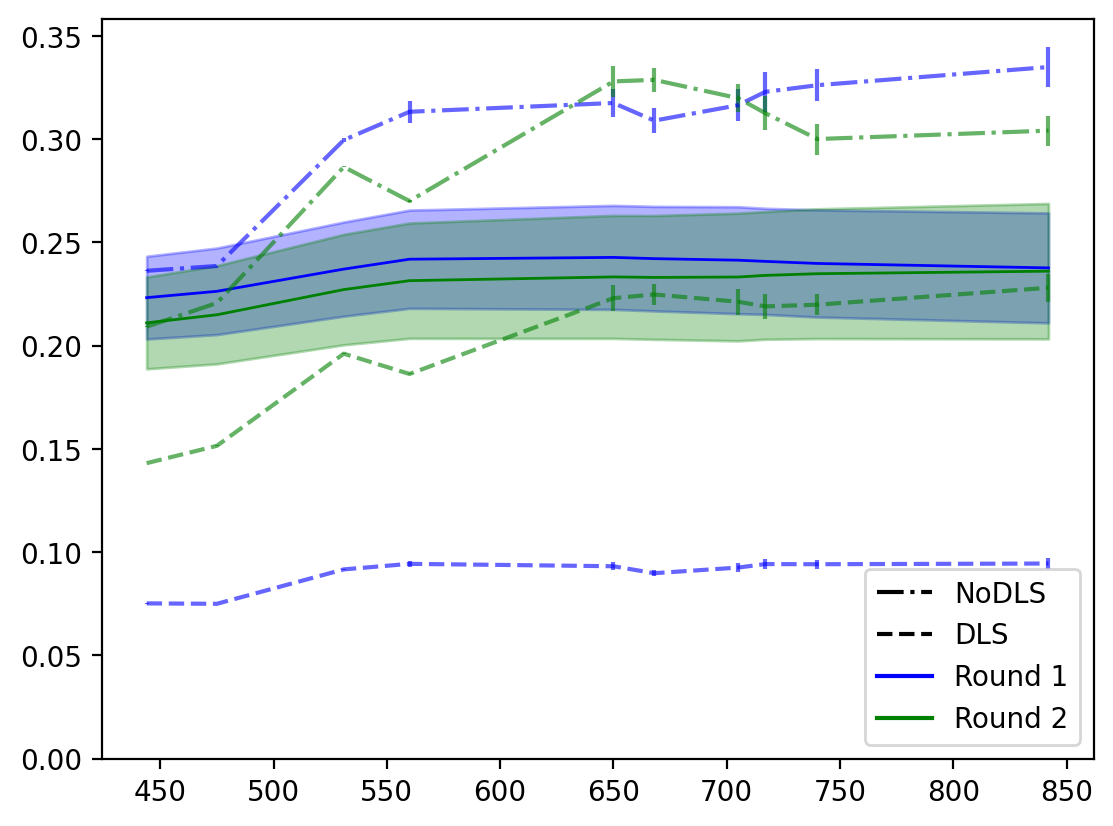

In [97]:
df_all_groundtruth_spectra_stats_10B = df_all_groundtruth_spectra_stats.drop(columns='NDVI740')

fig, ax = plt.subplots()
ROUND_COLORS = {1: 'blue', 2: 'green'}
LINESTYLES = ['-.', '--']
# Associate the linestyles to dls modes
DLS_MODES_LINESTYLES = {dls_mode: LINESTYLES[i] for i, dls_mode in enumerate(DLS_MODES)}


for round_ in [1, 2]:
    y = df_all_groundtruth_spectra_stats_10B.xs("mean", level=1, axis=1).loc[
        ("westham", round_, "grey")
    ]
    x = y.index.to_numpy(dtype=float)
    y = y.to_numpy(dtype=float)
    ystd = df_all_groundtruth_spectra_stats_10B.xs("std", level=1, axis=1).loc[
        ("westham", round_, "grey")
    ].to_numpy(dtype=float)
    ax.plot(x,y,'-', linewidth=1, color=ROUND_COLORS[round_])#, label=f"Round {round_}")
    # Plot the standard deviation shade
    ax.fill_between(x, y+ystd, y-ystd, color=ROUND_COLORS[round_], alpha=0.3)

    geometry = gdf.loc[(round_, 'grey'), "geometry"]

    for dls_mode in DLS_MODES:
        tarp_spectra = extract_spectra_in_polygon(
            raster_path=df_raster_path_in_container.loc[(site, round_, dls_mode), "vsiaz_path"],
            geometry=geometry,
            band_indexes=SOURCE_BANDS_11B_TO_10B,
            wavelengths_nm=MICASENSE_10B_CENTER_WAVELENGTHS,
        )
        tarp_spectra_stats = tarp_spectra.agg(["mean", "std"]).T
        x = tarp_spectra_stats.index.to_numpy(dtype=float)
        y = tarp_spectra_stats["mean"].to_numpy(dtype=float)
        y_std = tarp_spectra_stats["std"].to_numpy(dtype=float)
        ax.errorbar(x, y, yerr=y_std, linestyle=DLS_MODES_LINESTYLES[dls_mode], color=ROUND_COLORS[round_], alpha=0.6)
        # ax.plot(x, y, 's--', color=ROUND_COLORS[round_], linewidth=1, label=f"Tarp Round {round_}")

# Add legend for dls modes
for dls_mode, linestyle in DLS_MODES_LINESTYLES.items():
    ax.plot([], [], linestyle=linestyle, color='black', label=dls_mode)
for round_ in [1, 2]:
    ax.plot([], [], '-', color=ROUND_COLORS[round_], label=f"Round {round_}")

ax.set_ylim(bottom=0)
ax.legend()


# NDVI plots

In [ ]:
# def calculate_r2(observed, predicted):
#     """
#     Calculate R² relative to the 1:1 relationship.

#     observed: ground-truth values
#     predicted: imagery values
#     """
#     observed = np.asarray(observed, dtype=float)
#     predicted = np.asarray(predicted, dtype=float)

#     if len(observed) < 2:
#         return np.nan

#     ss_res = np.sum((observed - predicted) ** 2)
#     ss_tot = np.sum((observed - observed.mean()) ** 2)

#     # R² is undefined when all observed values are identical.
#     if np.isclose(ss_tot, 0):
#         return np.nan

#     return 1 - (ss_res / ss_tot)


# def format_r2(value):
#     """Format R² for plot labels."""
#     return "N/A" if np.isnan(value) else f"{value:.2f}"


# for site in SITES:
#     for round_ in ROUND_DATES:
#         imagery_subset = df_all_imagery_spectra_stats.xs(
#             (site, round_),
#             level=("site", "round"),
#         )

#         groundtruth_subset = df_all_groundtruth_spectra_stats.xs(
#             (site, round_),
#             level=("site", "round"),
#         )

#         stations_to_highlight = STATIONS_TO_HIGHLIGHT.get(
#             (site, round_),
#             [],
#         )

#         fig, ax = plt.subplots()

#         colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

#         for i, dls_mode in enumerate(DLS_MODES):
#             color = colors[i % len(colors)]

#             imagery_dls = imagery_subset.xs(
#                 dls_mode,
#                 level="dls_mode",
#             )

#             # Align imagery and ground-truth data by station ID.
#             plot_data = pd.concat(
#                 {
#                     "imagery_mean": imagery_dls["NDVI740"]["mean"],
#                     "imagery_std": imagery_dls["NDVI740"]["std"],
#                     "groundtruth_mean": groundtruth_subset["NDVI740"]["mean"],
#                     "groundtruth_std": groundtruth_subset["NDVI740"]["std"],
#                 },
#                 axis=1,
#                 join="inner",
#             ).dropna()

#             if plot_data.empty:
#                 print(f"No matching data for {site}, {round_}, {dls_mode}")
#                 continue

#             # Obtain station IDs from either an Index or MultiIndex.
#             if isinstance(plot_data.index, pd.MultiIndex):
#                 station_ids = plot_data.index.get_level_values("station_id")
#             else:
#                 station_ids = plot_data.index

#             highlight_mask = station_ids.isin(stations_to_highlight)

#             highlighted = plot_data.loc[highlight_mask]
#             background = plot_data.loc[~highlight_mask]

#             # R² using all aligned stations.
#             r2_all = calculate_r2(
#                 observed=plot_data["groundtruth_mean"],
#                 predicted=plot_data["imagery_mean"],
#             )

#             # R² using highlighted stations only.
#             if len(highlighted) >= 2:
#                 r2_highlighted = calculate_r2(
#                     observed=highlighted["groundtruth_mean"],
#                     predicted=highlighted["imagery_mean"],
#                 )
#             else:
#                 r2_highlighted = np.nan

#             mode_label = (
#                 f"{dls_mode}: "
#                 f"R² all={format_r2(r2_all)}, "
#                 f"highlighted={format_r2(r2_highlighted)}"
#             )

#             # Other stations: lighter points with error bars.
#             if not background.empty:
#                 ax.errorbar(
#                     x=background["groundtruth_mean"],
#                     xerr=background["groundtruth_std"],
#                     y=background["imagery_mean"],
#                     yerr=background["imagery_std"],
#                     fmt="o",
#                     color=color,
#                     ecolor=color,
#                     markersize=5,
#                     markeredgewidth=0,
#                     elinewidth=0.8,
#                     capsize=0,
#                     alpha=0.4,
#                     # Use the label here only when there are no
#                     # highlighted stations.
#                     label=(mode_label if highlighted.empty else "_nolegend_"),
#                     zorder=1,
#                 )

#             # Highlighted stations: prominent points and error bars.
#             if not highlighted.empty:
#                 ax.errorbar(
#                     x=highlighted["groundtruth_mean"],
#                     xerr=highlighted["groundtruth_std"],
#                     y=highlighted["imagery_mean"],
#                     yerr=highlighted["imagery_std"],
#                     fmt="o",
#                     color=color,
#                     ecolor=color,
#                     markeredgecolor="black",
#                     markeredgewidth=0.8,
#                     markersize=7,
#                     elinewidth=1.5,
#                     capsize=0,
#                     alpha=1.0,
#                     label=mode_label,
#                     zorder=2,
#                 )

#         # Add the 1:1 line.
#         min_val = 0
#         max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])

#         ax.plot(
#             [min_val, max_val],
#             [min_val, max_val],
#             linestyle="--",
#             color="gray",
#             label="1:1 line",
#             zorder=0,
#         )

#         ax.set_xlim(min_val, max_val)
#         ax.set_ylim(min_val, max_val)

#         ax.set_title(f"NDVI740 Comparison — {site.title()}, round {round_}")
#         ax.set_xlabel("Ground-truth")
#         ax.set_ylabel("Imagery")

#         ax.legend()
#         plt.show()


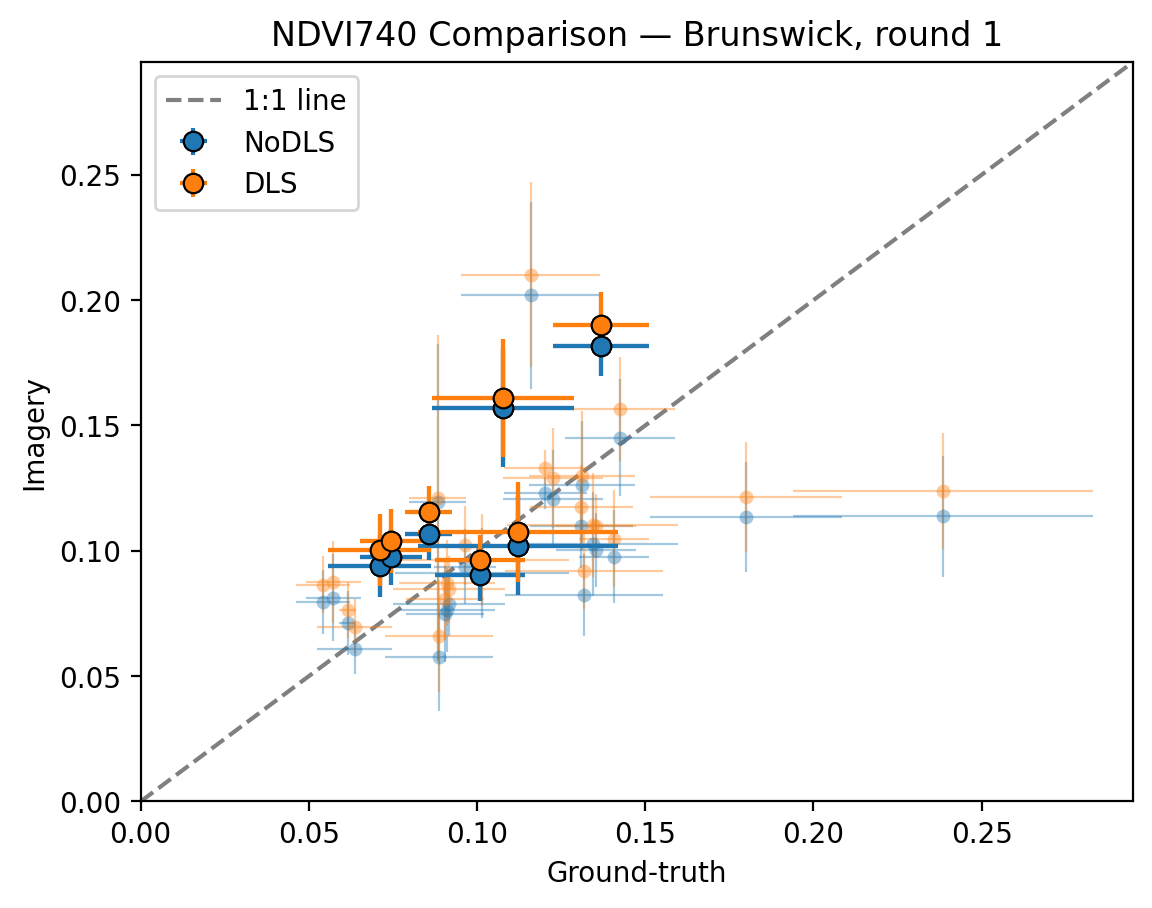

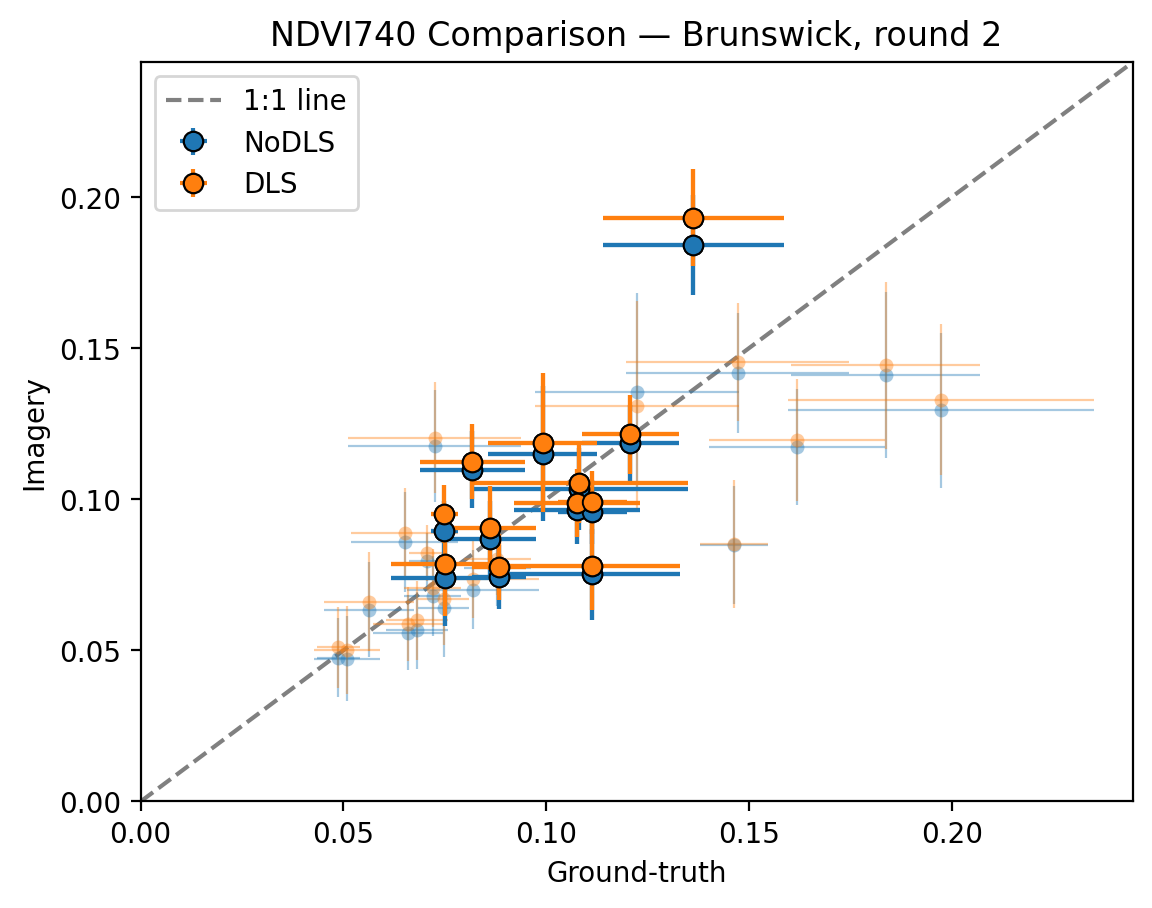

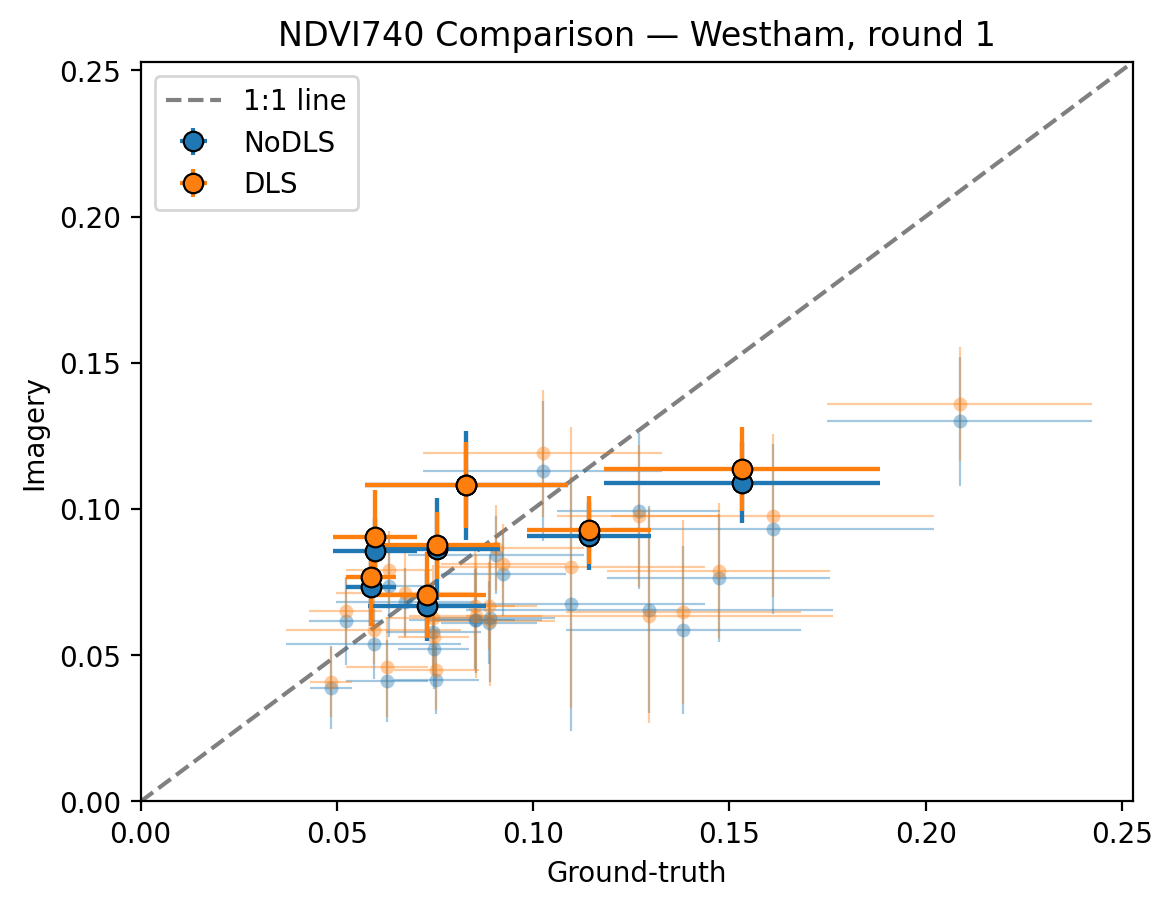

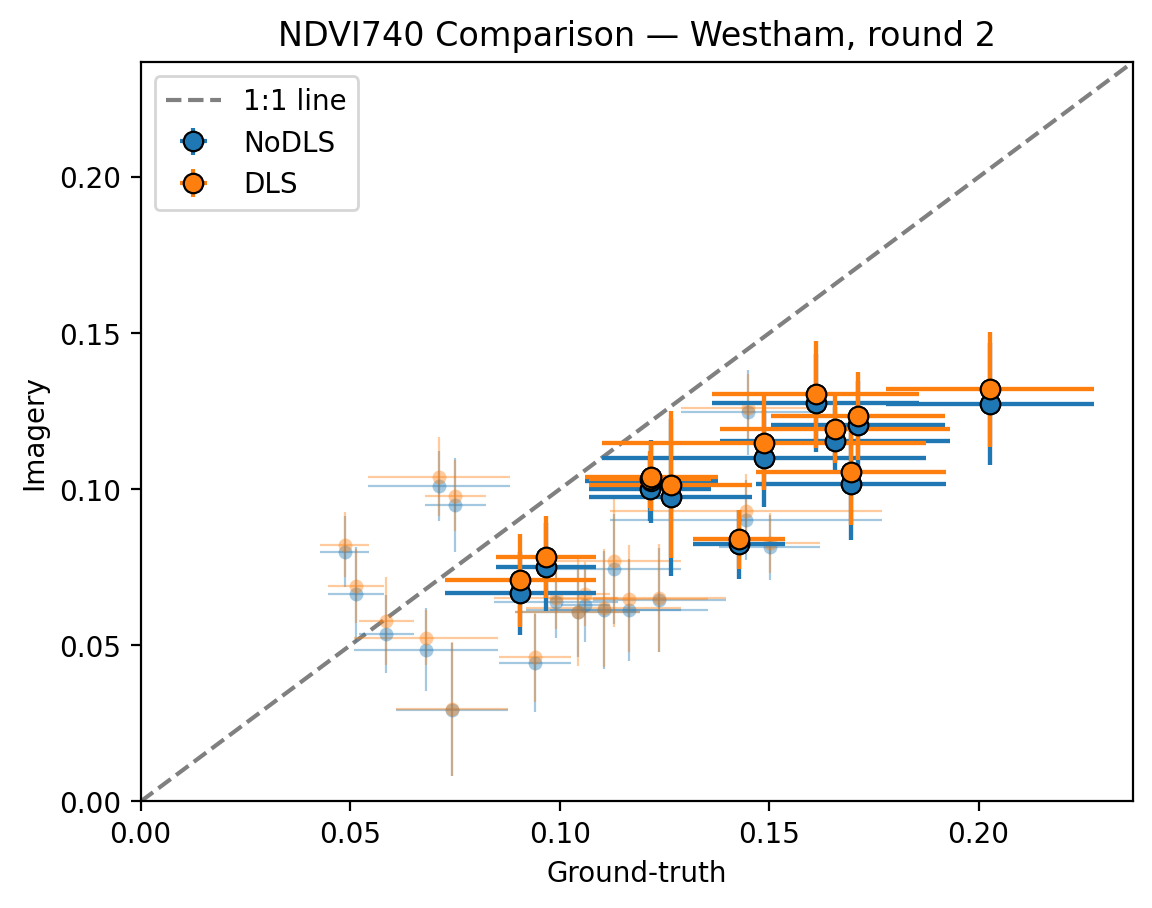

In [ ]:
for site in SITES:
    for round_ in ROUND_DATES:
        imagery_subset = df_all_imagery_spectra_stats.xs(
            (site, round_),
            level=("site", "round"),
        )

        groundtruth_subset = df_all_groundtruth_spectra_stats.xs(
            (site, round_),
            level=("site", "round"),
        )

        stations_to_highlight = STATIONS_TO_HIGHLIGHT.get(
            (site, round_),
            [],
        )

        fig, ax = plt.subplots()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for i, dls_mode in enumerate(DLS_MODES):
            color = colors[i % len(colors)]

            imagery_dls = imagery_subset.xs(
                dls_mode,
                level="dls_mode",
            )

            # Align imagery and ground-truth data by station ID.
            plot_data = pd.concat(
                {
                    "imagery_mean": imagery_dls["NDVI740"]["mean"],
                    "imagery_std": imagery_dls["NDVI740"]["std"],
                    "groundtruth_mean": groundtruth_subset["NDVI740"]["mean"],
                    "groundtruth_std": groundtruth_subset["NDVI740"]["std"],
                },
                axis=1,
                join="inner",
            ).dropna()

            if plot_data.empty:
                print(
                    f"No matching data for "
                    f"{site}, {round_}, {dls_mode}"
                )
                continue

            # Obtain station IDs from either a regular Index or MultiIndex.
            if isinstance(plot_data.index, pd.MultiIndex):
                station_ids = plot_data.index.get_level_values("station_id")
            else:
                station_ids = plot_data.index

            highlight_mask = station_ids.isin(stations_to_highlight)

            highlighted = plot_data.loc[highlight_mask]
            background = plot_data.loc[~highlight_mask]

            # All other stations: lighter points with visible error bars.
            if not background.empty:
                ax.errorbar(
                    x=background["groundtruth_mean"],
                    xerr=background["groundtruth_std"],
                    y=background["imagery_mean"],
                    yerr=background["imagery_std"],
                    fmt="o",
                    color=color,
                    ecolor=color,
                    markersize=5,
                    markeredgewidth=0,
                    elinewidth=0.8,
                    capsize=0,
                    alpha=0.4,
                    label="_nolegend_",
                    zorder=1,
                )

            # Selected stations: prominent points with stronger error bars.
            if not highlighted.empty:
                ax.errorbar(
                    x=highlighted["groundtruth_mean"],
                    xerr=highlighted["groundtruth_std"],
                    y=highlighted["imagery_mean"],
                    yerr=highlighted["imagery_std"],
                    fmt="o",
                    color=color,
                    ecolor=color,
                    markeredgecolor="black",
                    markeredgewidth=0.8,
                    markersize=7,
                    elinewidth=1.5,
                    capsize=0,
                    alpha=1.0,
                    label=dls_mode,
                    zorder=2,
                )

            # Selected stations: prominent points with error bars.
            if not highlighted.empty:
                ax.errorbar(
                    x=highlighted["groundtruth_mean"],
                    xerr=highlighted["groundtruth_std"],
                    y=highlighted["imagery_mean"],
                    yerr=highlighted["imagery_std"],
                    fmt="o",
                    color=color,
                    markeredgecolor="black",
                    markeredgewidth=0.7,
                    markersize=7,
                    capsize=0,
                    alpha=1.0,
                    # label=dls_mode,
                    zorder=2,
                )

        # Add 1:1 line.
        min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
        max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
        min_val = 0

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
            color="gray",
            label="1:1 line",
            zorder=0,
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.set_title(
            f"NDVI740 Comparison — {site.title()}, round {round_}"
        )
        ax.set_xlabel("Ground-truth")
        ax.set_ylabel("Imagery")

        ax.legend()
        plt.show()

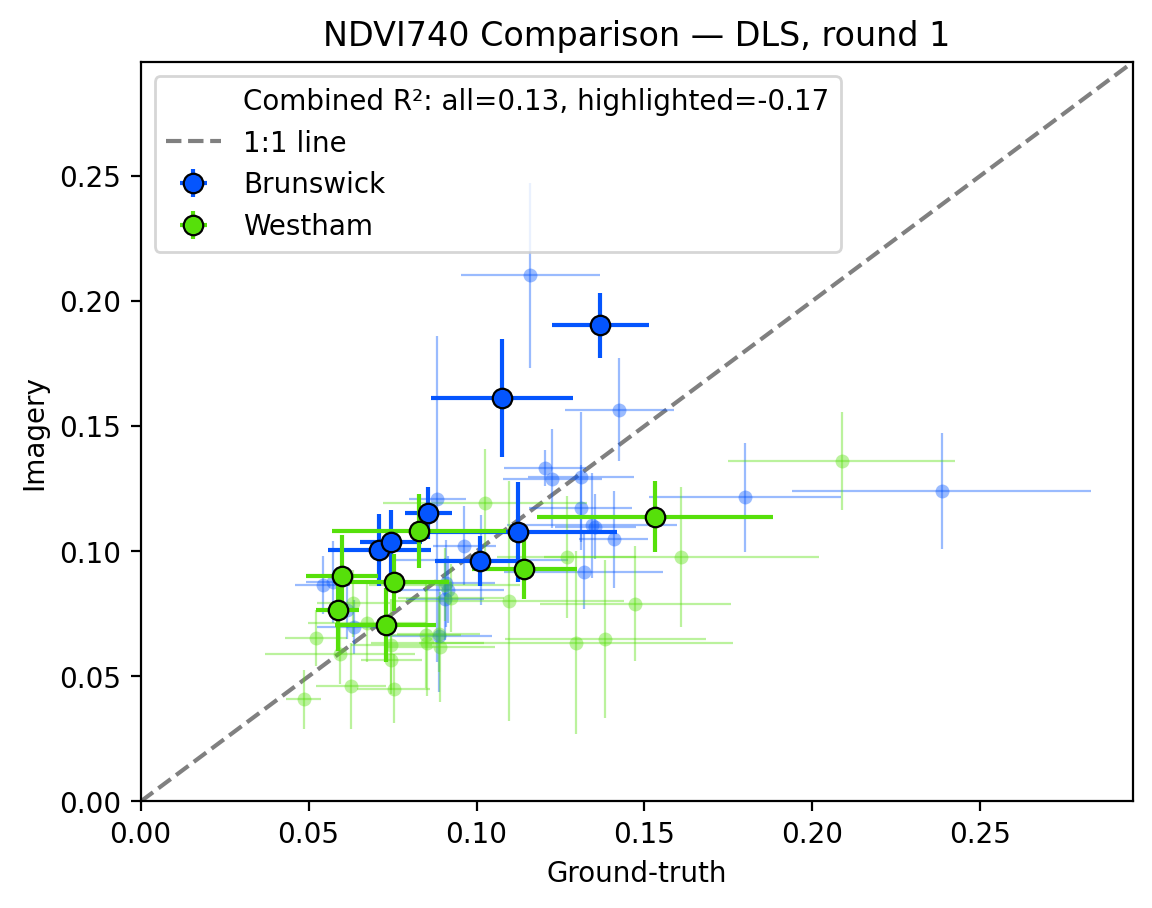

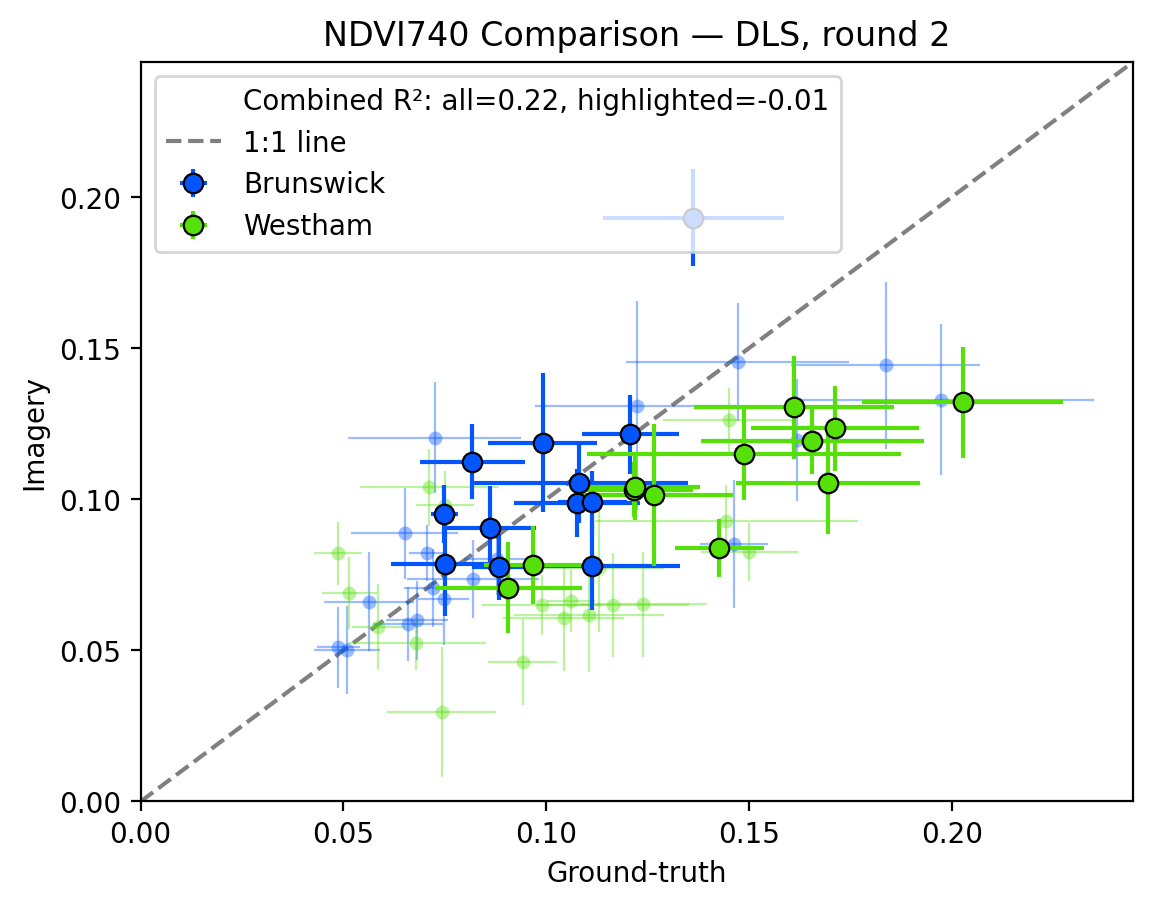

In [ ]:
DLS_MODE = "DLS"

SITES_TO_PLOT = [
    "brunswick",
    "westham",
]

SITE_COLORS = {
    "westham": "#56E00A",
    "brunswick": "#0455FE",
}


for round_ in ROUND_DATES:
    fig, ax = plt.subplots()

    # Store aligned data for both sites before calculating R².
    site_plot_data = {}

    for site in SITES_TO_PLOT:
        try:
            imagery_subset = df_all_imagery_spectra_stats.xs(
                (site, round_, DLS_MODE),
                level=("site", "round", "dls_mode"),
            )

            groundtruth_subset = df_all_groundtruth_spectra_stats.xs(
                (site, round_),
                level=("site", "round"),
            )

        except KeyError:
            print(f"No data for {site}, round {round_}, mode {DLS_MODE}")
            continue

        # Align imagery and ground-truth values by station ID.
        plot_data = pd.concat(
            {
                "imagery_mean": imagery_subset["NDVI740"]["mean"],
                "imagery_std": imagery_subset["NDVI740"]["std"],
                "groundtruth_mean": (groundtruth_subset["NDVI740"]["mean"]),
                "groundtruth_std": (groundtruth_subset["NDVI740"]["std"]),
            },
            axis=1,
            join="inner",
        ).dropna()

        if plot_data.empty:
            print(f"No matching data for {site}, round {round_}")
            continue

        # Get the station IDs.
        if isinstance(plot_data.index, pd.MultiIndex):
            station_ids = plot_data.index.get_level_values("station_id")
        else:
            station_ids = plot_data.index

        stations_to_highlight = STATIONS_TO_HIGHLIGHT.get(
            (site, round_),
            [],
        )

        # Record highlighted status before combining sites.
        plot_data = plot_data.copy()
        plot_data["highlighted"] = station_ids.isin(stations_to_highlight)

        site_plot_data[site] = plot_data

    if not site_plot_data:
        plt.close(fig)
        continue

    # Combine Brunswick and Westham into one DataFrame.
    combined_plot_data = pd.concat(
        site_plot_data,
        names=["site"],
    )

    combined_highlighted = combined_plot_data.loc[combined_plot_data["highlighted"]]

    # R² across all stations from both sites.
    r2_all = calculate_r2(
        observed=combined_plot_data["groundtruth_mean"],
        predicted=combined_plot_data["imagery_mean"],
    )

    # R² across highlighted stations from both sites.
    r2_highlighted = calculate_r2(
        observed=combined_highlighted["groundtruth_mean"],
        predicted=combined_highlighted["imagery_mean"],
    )

    # Plot each site using its specified color.
    for site, plot_data in site_plot_data.items():
        color = SITE_COLORS[site]

        highlighted = plot_data.loc[plot_data["highlighted"]]

        background = plot_data.loc[~plot_data["highlighted"]]

        # Other stations with lighter error bars.
        if not background.empty:
            ax.errorbar(
                x=background["groundtruth_mean"],
                xerr=background["groundtruth_std"],
                y=background["imagery_mean"],
                yerr=background["imagery_std"],
                fmt="o",
                color=color,
                ecolor=color,
                markersize=5,
                markeredgewidth=0,
                elinewidth=0.8,
                capsize=0,
                alpha=0.4,
                label=(site.title() if highlighted.empty else "_nolegend_"),
                zorder=1,
            )

        # Highlighted stations.
        if not highlighted.empty:
            ax.errorbar(
                x=highlighted["groundtruth_mean"],
                xerr=highlighted["groundtruth_std"],
                y=highlighted["imagery_mean"],
                yerr=highlighted["imagery_std"],
                fmt="o",
                color=color,
                ecolor=color,
                markeredgecolor="black",
                markeredgewidth=0.8,
                markersize=7,
                elinewidth=1.5,
                capsize=0,
                alpha=1.0,
                label=site.title(),
                zorder=2,
            )

    # Add the combined R² values as a separate legend entry.
    combined_r2_label = (
        f"Combined R²: all={format_r2(r2_all)}, highlighted={format_r2(r2_highlighted)}"
    )

    ax.plot(
        [],
        [],
        linestyle="none",
        marker="",
        label=combined_r2_label,
    )

    # Add 1:1 line.
    min_val = 0
    max_val = max(
        ax.get_xlim()[1],
        ax.get_ylim()[1],
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="gray",
        label="1:1 line",
        zorder=0,
    )

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    ax.set_title(f"NDVI740 Comparison — DLS, round {round_}")
    ax.set_xlabel("Ground-truth")
    ax.set_ylabel("Imagery")

    ax.legend()
    plt.show()


# Correction coeff

## 1. Imports and project configuration

In [98]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


def find_project_root(start=None):
    """Find the nearest parent containing data/ or src/."""
    start = Path(start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate

    return start


PROJECT_ROOT = find_project_root()

STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"

# Coefficient derivation notebooks currently save their reusable tables under
# PROJECT_ROOT/data/processed, so coefficient loading below is local by default.
#
# Azure remains useful later for the imagery and station-polygon inputs.
CONFIGURE_AZURE = True

if CONFIGURE_AZURE:
    try:
        import hatfield_funcs as hf

        hf.config.configure_azure()
        hf.config.configure_data_root_path(CONTAINER_NAME)

        os.environ.setdefault(
            "AZURE_STORAGE_ACCOUNT",
            STORAGE_ACCOUNT_NAME,
        )
        os.environ.setdefault(
            "GDAL_AZURE_USE_MSI",
            "YES",
        )
        os.environ.setdefault(
            "GDAL_CACHEMAX",
            "512",
        )

    except ImportError:
        warnings.warn(
            "hatfield_funcs is unavailable. This does not prevent local "
            "coefficient loading, but Azure imagery access must already be "
            "configured before the extraction section is added."
        )


def container_path(path, container_name=CONTAINER_NAME):
    """Convert a container-relative path to a GDAL /vsiaz/ path."""
    normalized = str(path).replace("\\", "/").lstrip("/")
    return f"/vsiaz/{container_name}/{normalized}"


print("Project root:", PROJECT_ROOT)


Project root: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm


## 2. Dates, sites, DLS modes, and band metadata

In [99]:
ROUNDS = [1, 2]

ROUND_DATES = {
    1: "2026-05-04",
    2: "2026-05-18",
}

DATE_TO_ROUND = {
    flight_date: round_number
    for round_number, flight_date in ROUND_DATES.items()
}

DATES = list(ROUND_DATES.values())
SITES = ["westham", "brunswick"]
DLS_MODES = ["DLS", "NoDLS"]

SOURCE_BAND_NUMBERS = list(range(1, 12))

# The source rasters contain 11 bands. Source band 5 is PAN.
SOURCE_BAND_NAMES = [
    "B1",
    "B2",
    "B3",
    "B4",
    "PAN",
    "B5",
    "B6",
    "B7",
    "B8",
    "B9",
    "B10",
]

SPECTRAL_WAVELENGTHS_NM = {
    "B1": 444,
    "B2": 475,
    "B3": 531,
    "B4": 560,
    "B5": 650,
    "B6": 668,
    "B7": 705,
    "B8": 717,
    "B9": 740,
    "B10": 842,
}

SPECTRAL_BAND_NAMES = list(SPECTRAL_WAVELENGTHS_NM)

BAND_METADATA = pd.DataFrame({
    "source_band": SOURCE_BAND_NUMBERS,
    "band_name": SOURCE_BAND_NAMES,
})

BAND_METADATA["band_index"] = np.arange(len(BAND_METADATA))
BAND_METADATA["wavelength_nm"] = (
    BAND_METADATA["band_name"].map(SPECTRAL_WAVELENGTHS_NM)
)
BAND_METADATA["is_pan"] = BAND_METADATA["band_name"].eq("PAN")

# The old comparison notebook used these wavelengths for NDVI740.
NDVI_RED_NM = 668
NDVI_NIR_NM = 740

RED_BAND_NAME = {
    wavelength: band
    for band, wavelength in SPECTRAL_WAVELENGTHS_NM.items()
}[NDVI_RED_NM]

NIR_BAND_NAME = {
    wavelength: band
    for band, wavelength in SPECTRAL_WAVELENGTHS_NM.items()
}[NDVI_NIR_NM]

display(BAND_METADATA)
print("NDVI bands:", RED_BAND_NAME, "and", NIR_BAND_NAME)


,source_band,band_name,band_index,wavelength_nm,is_pan
0,1,B1,0,444.0,False
1,2,B2,1,475.0,False
2,3,B3,2,531.0,False
3,4,B4,3,560.0,False
4,5,PAN,4,NaN,True
5,6,B5,5,650.0,False
6,7,B6,6,668.0,False
7,8,B7,7,705.0,False
8,9,B8,8,717.0,False
9,10,B9,9,740.0,False


NDVI bands: B6 and B9


## 3. Saved coefficient paths

In [100]:
RADIOMETRY_EVAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
)

TEMPORAL_OUTPUT_DIR = (
    RADIOMETRY_EVAL_DIR
    / "polygon_pixel_spectra"
)

SPATIAL_OUTPUT_DIR = (
    RADIOMETRY_EVAL_DIR
    / "bidirectional_spatial_coefficients"
)

# Set either variable to a specific CSV/Parquet/Pickle path if automatic
# discovery selects the wrong file.
TEMPORAL_COEFFICIENT_PATH = None

SPATIAL_COEFFICIENT_PATH = (
    SPATIAL_OUTPUT_DIR
    / "all_bidirectional_spatial_coefficients.csv"
)

print("Temporal coefficient directory:", TEMPORAL_OUTPUT_DIR)
print("Spatial coefficient table:", SPATIAL_COEFFICIENT_PATH)


Temporal coefficient directory: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra
Spatial coefficient table: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients/all_bidirectional_spatial_coefficients.csv


## 4. Generic coefficient-table helpers

In [101]:
def read_table(path):
    """Read a coefficient table from CSV, Parquet, or Pickle."""
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".csv" or ".csv" in [s.lower() for s in path.suffixes]:
        return pd.read_csv(path)

    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)

    if suffix in {".pkl", ".pickle"}:
        return pd.read_pickle(path)

    raise ValueError(f"Unsupported table format: {path}")


def normalize_coefficient_columns(table):
    """Normalize older/newer coefficient column names."""
    result = table.rename(columns={
        "slope": "gain",
        "intercept": "offset",
        "band": "band_name",
        "date": "flight_date",
        "mode": "dls_mode",
    }).copy()

    required = {"band_name", "gain", "offset"}
    missing = required - set(result.columns)

    if missing:
        raise KeyError(
            f"Coefficient table is missing required columns: {sorted(missing)}"
        )

    result["band_name"] = result["band_name"].astype(str)

    if "wavelength_nm" not in result.columns:
        result["wavelength_nm"] = (
            result["band_name"].map(SPECTRAL_WAVELENGTHS_NM)
        )

    return result


def is_coefficient_table(table):
    columns = {str(column).lower() for column in table.columns}

    return (
        ("gain" in columns or "slope" in columns)
        and ("offset" in columns or "intercept" in columns)
        and ("band_name" in columns or "band" in columns)
    )


def validate_numeric_coefficients(table, table_name):
    for column in ["gain", "offset"]:
        values = pd.to_numeric(table[column], errors="coerce")
        if values.isna().any() or not np.isfinite(values.to_numpy()).all():
            raise ValueError(
                f"{table_name}: column {column!r} contains non-finite values."
            )
        table[column] = values.astype(float)

    return table


## 5. Load saved temporal coefficients

In [102]:
def temporal_candidate_paths():
    # The first name is the table observed in the current derivation workflow.
    preferred_names = [
        "temporal_radiometric_correction_coefficients.csv",
        "temporal_radiometric_correction_coefficients.parquet",
        "all_temporal_coefficients.csv",
        "all_temporal_coefficients.parquet",
        "temporal_coefficients.csv",
        "temporal_coefficients.parquet",
        "temporal_correction_coefficients.csv",
        "temporal_correction_coefficients.parquet",
    ]

    candidates = []

    for name in preferred_names:
        path = TEMPORAL_OUTPUT_DIR / name
        if path.exists():
            candidates.append(path)

    if TEMPORAL_OUTPUT_DIR.exists():
        valid_suffixes = {
            ".csv", ".parquet", ".pq", ".pkl", ".pickle",
        }

        for path in TEMPORAL_OUTPUT_DIR.rglob("*"):
            if not path.is_file():
                continue

            lower_name = path.name.lower()

            if path.suffix.lower() not in valid_suffixes:
                continue
            if "bootstrap" in lower_name:
                continue
            if "temporal" not in lower_name or "coeff" not in lower_name:
                continue
            if path not in candidates:
                candidates.append(path)

    return candidates


def compact_token(value):
    return (
        str(value)
        .lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )


def infer_temporal_site(row):
    if "site" in row.index and pd.notna(row["site"]):
        return str(row["site"]).strip().lower()

    text = " ".join(
        str(row.get(column, ""))
        for column in [
            "transform_name",
            "source_site",
            "destination_site",
        ]
    ).lower()

    if "brunswick" in text:
        return "brunswick"
    if "westham" in text:
        return "westham"

    return None


def infer_temporal_mode(row):
    if "dls_mode" in row.index and pd.notna(row["dls_mode"]):
        value = str(row["dls_mode"]).strip().lower()
        return "NoDLS" if value == "nodls" else "DLS"

    text = str(row.get("transform_name", "")).lower()

    if "nodls" in text:
        return "NoDLS"
    if "dls" in text:
        return "DLS"

    return None


def infer_temporal_direction(row):
    if "direction" in row.index and pd.notna(row["direction"]):
        text = compact_token(row["direction"])
    else:
        text = compact_token(
            " ".join(
                str(row.get(column, ""))
                for column in [
                    "transform_name",
                    "source_date",
                    "destination_date",
                    "from_date",
                    "to_date",
                ]
            )
        )

    # Prefer explicit source/destination date columns when present.
    for source_column, destination_column in [
        ("source_date", "destination_date"),
        ("from_date", "to_date"),
    ]:
        if (
            source_column in row.index
            and destination_column in row.index
            and pd.notna(row[source_column])
            and pd.notna(row[destination_column])
        ):
            source = compact_token(row[source_column])
            destination = compact_token(row[destination_column])

            if source.endswith("0504") and destination.endswith("0518"):
                return "may4_to_may18"

            if source.endswith("0518") and destination.endswith("0504"):
                return "may18_to_may4"

    may4_tokens = ["may4", "may04", "0504", "20260504"]
    may18_tokens = ["may18", "0518", "20260518"]

    may4_positions = [
        text.find(token) for token in may4_tokens if token in text
    ]
    may18_positions = [
        text.find(token) for token in may18_tokens if token in text
    ]

    if may4_positions and may18_positions:
        return (
            "may4_to_may18"
            if min(may4_positions) < min(may18_positions)
            else "may18_to_may4"
        )

    return None


def load_saved_temporal_coefficients():
    if TEMPORAL_COEFFICIENT_PATH is not None:
        paths = [Path(TEMPORAL_COEFFICIENT_PATH)]
    else:
        paths = temporal_candidate_paths()

    compatible = []

    for path in paths:
        if not path.exists():
            continue

        try:
            table = read_table(path)
        except Exception as error:
            warnings.warn(f"Could not read temporal candidate {path}: {error}")
            continue

        if is_coefficient_table(table):
            compatible.append((path, table))

    if not compatible:
        candidates = "\n- ".join(map(str, paths)) if paths else "(none found)"
        raise FileNotFoundError(
            "No compatible temporal coefficient table was found. "
            "Set TEMPORAL_COEFFICIENT_PATH explicitly.\n"
            f"Candidates checked:\n- {candidates}"
        )

    source_path, table = compatible[0]

    table = normalize_coefficient_columns(table)
    table = validate_numeric_coefficients(table, "temporal coefficients")

    table = table.loc[
        table["band_name"].isin(SOURCE_BAND_NAMES)
    ].copy()

    table["site"] = table.apply(infer_temporal_site, axis=1)
    table["dls_mode"] = table.apply(infer_temporal_mode, axis=1)
    table["direction"] = table.apply(
        infer_temporal_direction,
        axis=1,
    )
    table["source_path"] = str(source_path)

    invalid = table.loc[
        ~table["site"].isin(SITES)
        | ~table["dls_mode"].isin(DLS_MODES)
        | ~table["direction"].isin([
            "may4_to_may18",
            "may18_to_may4",
        ])
    ]

    if not invalid.empty:
        display(invalid)
        raise ValueError(
            "Could not infer temporal site, DLS mode, or direction for "
            f"{len(invalid)} coefficient rows."
        )

    # Prefer rows whose transform name indicates a per-band fit if the source
    # table contains both pooled/common-slope and per-band products.
    if "transform_name" in table.columns:
        table["_per_band_preference"] = (
            table["transform_name"]
            .astype(str)
            .str.lower()
            .str.contains(r"band|per_band", regex=True)
            .astype(int)
        )
    else:
        table["_per_band_preference"] = 0

    key = [
        "site",
        "dls_mode",
        "direction",
        "band_name",
    ]

    table = (
        table.sort_values(
            "_per_band_preference",
            ascending=False,
        )
        .drop_duplicates(key, keep="first")
        .drop(columns="_per_band_preference")
        .reset_index(drop=True)
    )

    print("Loaded temporal coefficients:")
    print(" ", source_path)
    print(" Rows:", len(table))

    return table


temporal_coefficients = load_saved_temporal_coefficients()

display(
    temporal_coefficients[
        [
            "site",
            "dls_mode",
            "direction",
            "band_name",
            "wavelength_nm",
            "gain",
            "offset",
            "source_path",
        ]
    ]
)


Loaded temporal coefficients:
  /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_radiometric_correction_coefficients.csv
 Rows: 88


,site,dls_mode,direction,band_name,wavelength_nm,gain,offset,source_path
0,brunswick,DLS,may4_to_may18,B1,444.0,3.322972,0.005612,/home/coder/jchampion/Biofilm_LEG13553/confide...
1,brunswick,DLS,may4_to_may18,B2,475.0,3.305021,0.013407,/home/coder/jchampion/Biofilm_LEG13553/confide...
2,brunswick,DLS,may4_to_may18,B3,531.0,3.713462,0.006976,/home/coder/jchampion/Biofilm_LEG13553/confide...
3,brunswick,DLS,may4_to_may18,B4,560.0,3.830207,0.009351,/home/coder/jchampion/Biofilm_LEG13553/confide...
4,brunswick,DLS,may4_to_may18,PAN,NaN,4.407117,-0.000657,/home/coder/jchampion/Biofilm_LEG13553/confide...
5,brunswick,DLS,may4_to_may18,B5,650.0,4.056863,0.017515,/home/coder/jchampion/Biofilm_LEG13553/confide...
6,brunswick,DLS,may4_to_may18,B6,668.0,4.268245,0.015838,/home/coder/jchampion/Biofilm_LEG13553/confide...
7,brunswick,DLS,may4_to_may18,B7,705.0,4.337333,0.009573,/home/coder/jchampion/Biofilm_LEG13553/confide...
8,brunswick,DLS,may4_to_may18,B8,717.0,4.233381,0.007445,/home/coder/jchampion/Biofilm_LEG13553/confide...
9,brunswick,DLS,may4_to_may18,B9,740.0,4.295132,0.014169,/home/coder/jchampion/Biofilm_LEG13553/confide...


## 6. Load saved bidirectional spatial coefficients

In [103]:
def load_saved_spatial_coefficients():
    path = Path(SPATIAL_COEFFICIENT_PATH)

    if not path.exists():
        raise FileNotFoundError(
            "Bidirectional spatial coefficient table was not found:\n"
            f"{path}\n"
            "Run imagery_derive_bidirectional_spatial_coefficients.ipynb "
            "or set SPATIAL_COEFFICIENT_PATH explicitly."
        )

    table = normalize_coefficient_columns(read_table(path))
    table = validate_numeric_coefficients(table, "spatial coefficients")

    required = {
        "flight_date",
        "dls_mode",
        "direction",
        "source_site",
        "destination_site",
        "band_name",
        "gain",
        "offset",
    }

    missing = required - set(table.columns)

    if missing:
        raise KeyError(
            f"Spatial coefficient table is missing columns: {sorted(missing)}"
        )

    table["flight_date"] = table["flight_date"].astype(str)
    table["dls_mode"] = table["dls_mode"].astype(str)
    table["direction"] = table["direction"].astype(str)
    table["source_site"] = table["source_site"].astype(str).str.lower()
    table["destination_site"] = (
        table["destination_site"].astype(str).str.lower()
    )

    table = table.loc[
        table["band_name"].isin(SOURCE_BAND_NAMES)
    ].copy()

    key = [
        "flight_date",
        "dls_mode",
        "direction",
        "band_name",
    ]

    duplicates = table.loc[
        table.duplicated(key, keep=False),
        key,
    ]

    if not duplicates.empty:
        display(duplicates)
        raise ValueError("Duplicate spatial coefficient keys were found.")

    invalid_dates = sorted(
        set(table["flight_date"]) - set(DATES)
    )
    invalid_modes = sorted(
        set(table["dls_mode"]) - set(DLS_MODES)
    )

    if invalid_dates:
        warnings.warn(f"Unexpected spatial flight dates: {invalid_dates}")
    if invalid_modes:
        warnings.warn(f"Unexpected spatial DLS modes: {invalid_modes}")

    table["source_path"] = str(path)

    print("Loaded bidirectional spatial coefficients:")
    print(" ", path)
    print(" Rows:", len(table))

    return table.reset_index(drop=True)


spatial_coefficients = load_saved_spatial_coefficients()

quality_columns = [
    column
    for column in [
        "flight_date",
        "dls_mode",
        "direction",
        "source_site",
        "destination_site",
        "band_name",
        "wavelength_nm",
        "gain",
        "offset",
        "r2",
        "rmse",
        "gain_ci_low",
        "gain_ci_high",
        "offset_ci_low",
        "offset_ci_high",
        "bootstrap_success_fraction",
    ]
    if column in spatial_coefficients.columns
]

display(spatial_coefficients[quality_columns])


Loaded bidirectional spatial coefficients:
  /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients/all_bidirectional_spatial_coefficients.csv
 Rows: 88


,flight_date,dls_mode,direction,source_site,destination_site,band_name,wavelength_nm,gain,offset,r2,rmse,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high,bootstrap_success_fraction
0,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B1,444.0,2.114857,-0.006202,0.932768,0.001274,2.044310,2.187889,-0.006942,-0.005480,1.0
1,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B2,475.0,2.309573,-0.008369,0.920367,0.001297,2.223228,2.370699,-0.009045,-0.007410,1.0
2,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B3,531.0,2.474582,-0.012530,0.848961,0.001766,2.375975,2.573061,-0.013961,-0.011102,1.0
3,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B4,560.0,2.524686,-0.013741,0.798781,0.001992,2.344534,2.640773,-0.015556,-0.010983,1.0
4,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,PAN,NaN,2.318646,-0.008181,0.952628,0.001560,2.248004,2.405913,-0.009179,-0.007365,1.0
5,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B5,650.0,2.612838,-0.012723,0.884793,0.002044,2.544317,2.682466,-0.013700,-0.011760,1.0
6,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B6,668.0,2.624251,-0.011473,0.896295,0.001735,2.558526,2.693074,-0.012312,-0.010651,1.0
7,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B7,705.0,2.437036,-0.008783,0.982242,0.001339,2.400146,2.471633,-0.009187,-0.008358,1.0
8,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B8,717.0,2.249519,-0.005964,0.988696,0.001286,2.224313,2.276031,-0.006207,-0.005721,1.0
9,2026-05-04,DLS,brunswick_to_westham,brunswick,westham,B9,740.0,2.118759,-0.002110,0.994405,0.001148,2.097173,2.140551,-0.002201,-0.002006,1.0


## 7. Transform algebra and selectors

In [104]:
def coefficient_frame(table, name=None):
    """Return the core affine-transform columns in a consistent format."""
    result = normalize_coefficient_columns(table)

    core_columns = [
        "band_name",
        "wavelength_nm",
        "gain",
        "offset",
    ]

    result = result[core_columns].copy()

    if name is not None:
        result.insert(0, "transform_name", name)

    return result


def invert_transform(transform, name):
    """Algebraically invert destination = gain * source + offset."""
    transform = coefficient_frame(transform)

    if np.isclose(transform["gain"].to_numpy(float), 0).any():
        raise ZeroDivisionError("A transform gain is zero or approximately zero.")

    output = transform[
        ["band_name", "wavelength_nm"]
    ].copy()

    output["gain"] = 1.0 / transform["gain"].to_numpy(float)
    output["offset"] = (
        -transform["offset"].to_numpy(float)
        / transform["gain"].to_numpy(float)
    )
    output.insert(0, "transform_name", name)

    return output


def compose_transforms(first, second, name):
    """
    Compose second(first(x)).

    If:
        y = gain_first * x + offset_first
        z = gain_second * y + offset_second

    then:
        z = (gain_first * gain_second) * x
            + (offset_first * gain_second + offset_second)
    """
    first = coefficient_frame(first)
    second = coefficient_frame(second)

    merged = first.merge(
        second,
        on=["band_name", "wavelength_nm"],
        suffixes=("_first", "_second"),
        validate="one_to_one",
    )

    output = merged[
        ["band_name", "wavelength_nm"]
    ].copy()

    output["gain"] = (
        merged["gain_first"]
        * merged["gain_second"]
    )

    output["offset"] = (
        merged["offset_first"]
        * merged["gain_second"]
        + merged["offset_second"]
    )

    output.insert(0, "transform_name", name)

    return output


def identity_transform(name="identity", include_pan=True):
    bands = (
        SOURCE_BAND_NAMES
        if include_pan
        else SPECTRAL_BAND_NAMES
    )

    return pd.DataFrame({
        "transform_name": name,
        "band_name": bands,
        "wavelength_nm": [
            SPECTRAL_WAVELENGTHS_NM.get(band)
            for band in bands
        ],
        "gain": 1.0,
        "offset": 0.0,
    })


def temporal_transform(
    site,
    dls_mode,
    direction="may4_to_may18",
):
    selected = temporal_coefficients.loc[
        temporal_coefficients["site"].eq(site)
        & temporal_coefficients["dls_mode"].eq(dls_mode)
        & temporal_coefficients["direction"].eq(direction)
    ].copy()

    if selected.empty:
        reverse_direction = (
            "may18_to_may4"
            if direction == "may4_to_may18"
            else "may4_to_may18"
        )

        reverse = temporal_coefficients.loc[
            temporal_coefficients["site"].eq(site)
            & temporal_coefficients["dls_mode"].eq(dls_mode)
            & temporal_coefficients["direction"].eq(reverse_direction)
        ].copy()

        if reverse.empty:
            raise KeyError(
                "No temporal coefficients for "
                f"{site} | {dls_mode} | {direction}"
            )

        return invert_transform(
            reverse,
            f"{site}_{direction}_{dls_mode}_algebraic_inverse",
        )

    missing_bands = (
        set(SOURCE_BAND_NAMES)
        - set(selected["band_name"])
    )

    if missing_bands:
        raise ValueError(
            "Temporal transform is missing source bands: "
            f"{sorted(missing_bands)}"
        )

    return coefficient_frame(
        selected,
        f"{site}_{direction}_{dls_mode}",
    )


def spatial_transform(
    flight_date,
    dls_mode,
    direction="brunswick_to_westham",
):
    selected = spatial_coefficients.loc[
        spatial_coefficients["flight_date"].eq(flight_date)
        & spatial_coefficients["dls_mode"].eq(dls_mode)
        & spatial_coefficients["direction"].eq(direction)
    ].copy()

    if selected.empty:
        raise KeyError(
            "No spatial coefficients for "
            f"{flight_date} | {dls_mode} | {direction}"
        )

    missing_bands = (
        set(SOURCE_BAND_NAMES)
        - set(selected["band_name"])
    )

    if missing_bands:
        raise ValueError(
            "Spatial transform is missing source bands: "
            f"{sorted(missing_bands)}"
        )

    return coefficient_frame(
        selected,
        f"{direction}_{flight_date}_{dls_mode}",
    )


def apply_transform(
    frame,
    transform,
    bands=None,
    *,
    copy=True,
):
    """Apply a per-band affine transform to wide spectral columns."""
    output = frame.copy() if copy else frame
    coefficients = (
        coefficient_frame(transform)
        .set_index("band_name")
    )

    selected_bands = (
        list(bands)
        if bands is not None
        else [
            band
            for band in coefficients.index
            if band in output.columns
        ]
    )

    for band in selected_bands:
        if band not in output.columns:
            continue
        if band not in coefficients.index:
            raise KeyError(f"No coefficient for band {band!r}")

        gain = float(coefficients.loc[band, "gain"])
        offset = float(coefficients.loc[band, "offset"])

        output[band] = gain * output[band] + offset

    return output


def add_ndvi740(frame, output_column="ndvi740", *, copy=True):
    output = frame.copy() if copy else frame

    red = output[RED_BAND_NAME].astype(float)
    nir = output[NIR_BAND_NAME].astype(float)
    denominator = nir + red

    output[output_column] = np.where(
        np.isfinite(denominator) & ~np.isclose(denominator, 0),
        (nir - red) / denominator,
        np.nan,
    )

    return output


## 8. Confirm the coefficient selectors work

In [105]:
temporal_examples = pd.concat(
    [
        temporal_transform(site, mode)
        for site in SITES
        for mode in DLS_MODES
    ],
    ignore_index=True,
)

spatial_examples = pd.concat(
    [
        spatial_transform(
            flight_date,
            mode,
            direction,
        )
        for flight_date in DATES
        for mode in DLS_MODES
        for direction in [
            "brunswick_to_westham",
            "westham_to_brunswick",
        ]
    ],
    ignore_index=True,
)

print("Selected temporal rows:", len(temporal_examples))
print("Selected spatial rows:", len(spatial_examples))

display(temporal_examples.head(15))
display(spatial_examples.head(15))


Selected temporal rows: 44
Selected spatial rows: 88


,transform_name,band_name,wavelength_nm,gain,offset
0,westham_may4_to_may18_DLS,B1,444.0,3.317421,-0.070349
1,westham_may4_to_may18_DLS,B2,475.0,3.110570,-0.055765
2,westham_may4_to_may18_DLS,B3,531.0,2.772332,-0.038625
3,westham_may4_to_may18_DLS,B4,560.0,2.524046,-0.018025
4,westham_may4_to_may18_DLS,PAN,NaN,2.289083,-0.006060
5,westham_may4_to_may18_DLS,B5,650.0,2.480605,-0.011534
6,westham_may4_to_may18_DLS,B6,668.0,2.399322,-0.001746
7,westham_may4_to_may18_DLS,B7,705.0,2.307704,-0.001125
8,westham_may4_to_may18_DLS,B8,717.0,2.131956,0.004645
9,westham_may4_to_may18_DLS,B9,740.0,2.048874,0.015417


,transform_name,band_name,wavelength_nm,gain,offset
0,brunswick_to_westham_2026-05-04_DLS,B1,444.0,2.114857,-0.006202
1,brunswick_to_westham_2026-05-04_DLS,B2,475.0,2.309573,-0.008369
2,brunswick_to_westham_2026-05-04_DLS,B3,531.0,2.474582,-0.012530
3,brunswick_to_westham_2026-05-04_DLS,B4,560.0,2.524686,-0.013741
4,brunswick_to_westham_2026-05-04_DLS,PAN,NaN,2.318646,-0.008181
5,brunswick_to_westham_2026-05-04_DLS,B5,650.0,2.612838,-0.012723
6,brunswick_to_westham_2026-05-04_DLS,B6,668.0,2.624251,-0.011473
7,brunswick_to_westham_2026-05-04_DLS,B7,705.0,2.437036,-0.008783
8,brunswick_to_westham_2026-05-04_DLS,B8,717.0,2.249519,-0.005964
9,brunswick_to_westham_2026-05-04_DLS,B9,740.0,2.118759,-0.002110


## 9. Optional: construct a saved-coefficient calibration chain

The exact chain to apply depends on the comparison reference frame you choose.

For example, to transform **Brunswick May 4 NoDLS** imagery into the
**Westham May 18 NoDLS scope**, one possible chain is:

1. Brunswick May 4 → Westham May 4, using the saved spatial transform;
2. Westham May 4 → Westham May 18, using the saved Westham temporal transform.

The code below demonstrates the composition without applying any older
hard-coded absolute-panel coefficients.


In [106]:
brunswick_may4_to_westham_may4_nodls = spatial_transform(
    "2026-05-04",
    "NoDLS",
    "brunswick_to_westham",
)

westham_may4_to_westham_may18_nodls = temporal_transform(
    "westham",
    "NoDLS",
    "may4_to_may18",
)

brunswick_may4_to_westham_may18_nodls = compose_transforms(
    brunswick_may4_to_westham_may4_nodls,
    westham_may4_to_westham_may18_nodls,
    "brunswick_may4_to_westham_may18_NoDLS",
)

display(brunswick_may4_to_westham_may18_nodls)


,transform_name,band_name,wavelength_nm,gain,offset
0,brunswick_may4_to_westham_may18_NoDLS,B1,444.0,1.342224,-0.036752
1,brunswick_may4_to_westham_may18_NoDLS,B2,475.0,1.417326,-0.041130
2,brunswick_may4_to_westham_may18_NoDLS,B3,531.0,1.388511,-0.040890
3,brunswick_may4_to_westham_may18_NoDLS,B4,560.0,1.339590,-0.034046
4,brunswick_may4_to_westham_may18_NoDLS,PAN,NaN,1.111578,-0.004944
5,brunswick_may4_to_westham_may18_NoDLS,B5,650.0,1.304185,-0.033827
6,brunswick_may4_to_westham_may18_NoDLS,B6,668.0,1.330643,-0.034835
7,brunswick_may4_to_westham_may18_NoDLS,B7,705.0,1.206642,-0.023818
8,brunswick_may4_to_westham_may18_NoDLS,B8,717.0,1.022476,0.002539
9,brunswick_may4_to_westham_may18_NoDLS,B9,740.0,0.991950,0.007882


## 10. Next section to add

Continue here with the station workflow from the old working notebook:

- configure the new DLS/NoDLS raster paths;
- load `biofilm_2x2m_and_3x3m_quadrat_polygons.geojson`;
- normalize station, round, and site fields;
- extract all valid raster pixels inside each selected station polygon;
- summarize station spectra;
- choose and apply the desired temporal/spatial calibration chain;
- load the processed field-spectrometer table;
- join imagery and field records by round/site/station;
- compare the ten spectral bands and NDVI740.

The loaded reusable objects are:

- `temporal_coefficients`
- `spatial_coefficients`
- `temporal_transform(...)`
- `spatial_transform(...)`
- `invert_transform(...)`
- `compose_transforms(...)`
- `apply_transform(...)`
- `add_ndvi740(...)`


In [107]:
round_ = 1
date_ = "2026-05-04"

coeffs_w2b_dls = spatial_coefficients.query(
    "`direction` == 'westham_to_brunswick' and `dls_mode` == 'DLS' and `flight_date` == @date_"
).set_index("band_name").filter(["gain", "offset"])
# Drop the PAN band
coeffs_w2b_dls = coeffs_w2b_dls.drop("PAN")
# Rename index by the list in MICASENSE_10B_CENTER_WAVELENGTHS
coeffs_w2b_dls.index = MICASENSE_10B_CENTER_WAVELENGTHS
coeffs_w2b_dls

,gain,offset
444,0.441664,0.003443
475,0.403932,0.004160
531,0.351953,0.006341
560,0.332476,0.007161
650,0.351499,0.005683
668,0.351656,0.005057
705,0.403809,0.003743
717,0.440157,0.002727
740,0.469798,0.001017
842,0.489459,0.000499


In [108]:
df_all_imagery_spectra_before_mod = df_all_imagery_spectra.xs(('westham',round_,'DLS'), level=('site','round','dls_mode')).copy()
df_all_imagery_spectra_after_mod = df_all_imagery_spectra.xs(
    ("westham", round_, "DLS"), level=("site", "round", "dls_mode")
).copy()

# Apply correction
for col in df_all_imagery_spectra_after_mod.columns:
    if col != 'NDVI740':
        df_all_imagery_spectra_after_mod[col] = df_all_imagery_spectra_before_mod[col] * coeffs_w2b_dls.loc[col, "gain"] + coeffs_w2b_dls.loc[col, "offset"]
# Recompute NDVI 740
df_all_imagery_spectra_after_mod['NDVI740'] = (df_all_imagery_spectra_after_mod[740] - df_all_imagery_spectra_after_mod[668]) / (df_all_imagery_spectra_after_mod[740] + df_all_imagery_spectra_after_mod[668])


df_all_imagery_spectra_before_mod_stats = df_all_imagery_spectra_before_mod.groupby(
    level=["station_id"]
).agg(["mean", "std"])
df_all_imagery_spectra_after_mod_stats = df_all_imagery_spectra_after_mod.groupby(
    level=["station_id"]
).agg(["mean", "std"])

In [109]:
# y_before = df_all_imagery_spectra_before_mod_stats['NDVI740']['mean']
# y_after = df_all_imagery_spectra_after_mod_stats['NDVI740']['mean']
# x = df_all_groundtruth_spectra_stats.xs(("westham", 1), level=["site", "round"])[
#     "NDVI740"
# ]["mean"]

# fig, ax = plt.subplots()
# ax.scatter(x, y_before, color='r', label="Before Modification")
# ax.scatter(x, y_after, color='g', label="After Modification")
# # Add 1:1 line
# max_val = max(x.max(), y_before.max(), y_after.max())
# ax.plot([0, max_val], [0, max_val], 'k--', label="1:1 Line")
# ax.set_xlabel("Ground Truth NDVI740")
# ax.set_ylabel("Imagery NDVI740")
# ax.legend()
# plt.show()

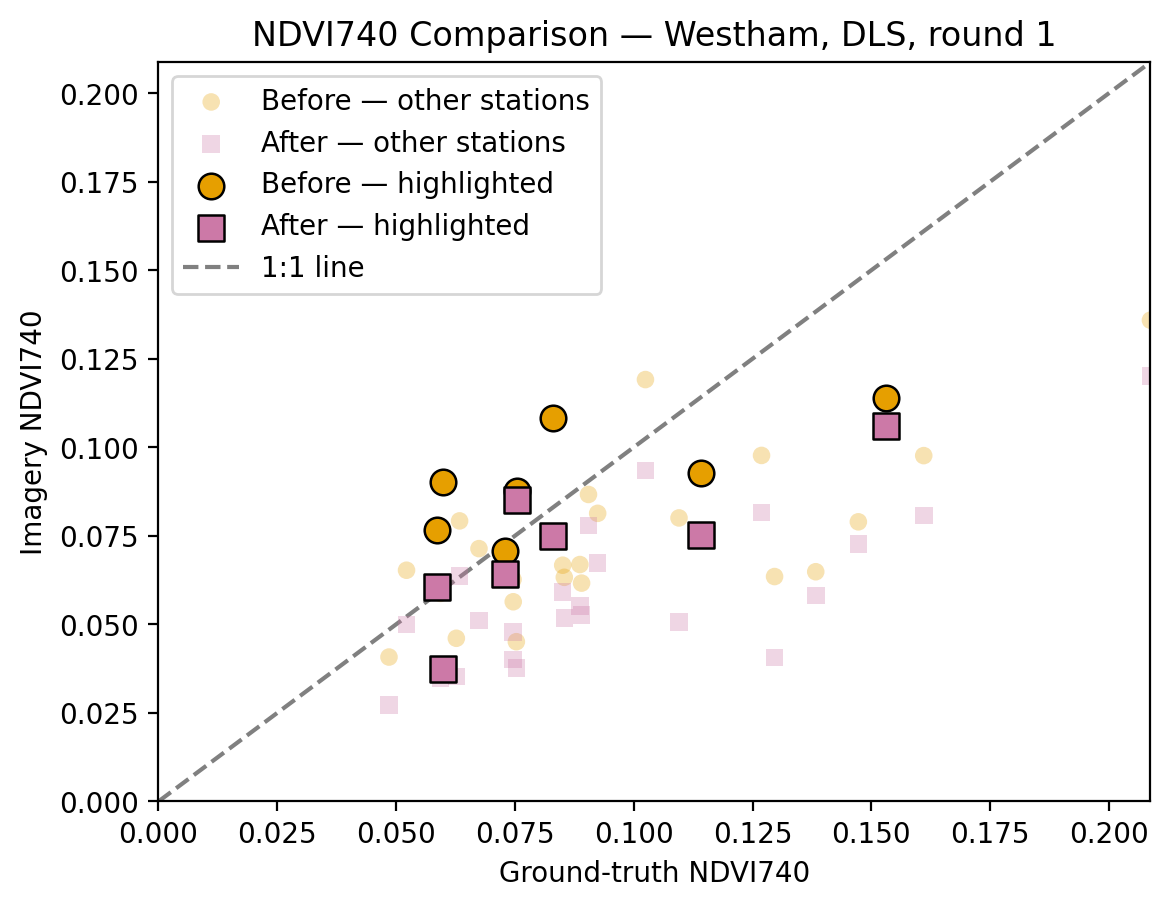

In [110]:
y_before = df_all_imagery_spectra_before_mod_stats["NDVI740"]["mean"]

y_after = df_all_imagery_spectra_after_mod_stats["NDVI740"]["mean"]

x = df_all_groundtruth_spectra_stats.xs(
    (site, round_),
    level=["site", "round"],
)["NDVI740"]["mean"]

# Align all three Series by station ID.
plot_data = pd.concat(
    {
        "groundtruth": x,
        "before": y_before,
        "after": y_after,
    },
    axis=1,
    join="inner",
).dropna()

# Get station IDs from the index.
if isinstance(plot_data.index, pd.MultiIndex):
    station_ids = plot_data.index.get_level_values("station_id")
else:
    station_ids = plot_data.index

stations_to_highlight = STATIONS_TO_HIGHLIGHT.get(
    ('westham', round_),
    [],
)

highlight_mask = station_ids.isin(stations_to_highlight)

highlighted = plot_data.loc[highlight_mask]
background = plot_data.loc[~highlight_mask]

fig, ax = plt.subplots()

before_color = "#E69F00"
after_color = "#CC79A7"

# Non-highlighted stations: faint background points.
if not background.empty:
    ax.scatter(
        background["groundtruth"],
        background["before"],
        color=before_color,
        marker="o",
        s=40,
        alpha=0.3,
        edgecolors="none",
        label="Before — other stations",
        zorder=1,
    )

    ax.scatter(
        background["groundtruth"],
        background["after"],
        color=after_color,
        marker="s",
        s=40,
        alpha=0.3,
        edgecolors="none",
        label="After — other stations",
        zorder=1,
    )

# Highlighted stations: larger points with black borders.
if not highlighted.empty:
    ax.scatter(
        highlighted["groundtruth"],
        highlighted["before"],
        color=before_color,
        marker="o",
        s=85,
        alpha=1,
        edgecolors="black",
        linewidths=0.9,
        label="Before — highlighted",
        zorder=2,
    )

    ax.scatter(
        highlighted["groundtruth"],
        highlighted["after"],
        color=after_color,
        marker="s",
        s=85,
        alpha=1,
        edgecolors="black",
        linewidths=0.9,
        label="After — highlighted",
        zorder=2,
    )

# Add the 1:1 line.
max_val = plot_data[["groundtruth", "before", "after"]].max().max()

ax.plot(
    [0, max_val],
    [0, max_val],
    color="gray",
    linestyle="--",
    label="1:1 line",
    zorder=0,
)

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

ax.set_title(f"NDVI740 Comparison — Westham, DLS, round {round_}")
ax.set_xlabel("Ground-truth NDVI740")
ax.set_ylabel("Imagery NDVI740")

ax.legend()
plt.show()


# Grey tarp spectra

In [111]:
site = 'westham'
gdf = gpd.read_file(POLYGON_PATHS[site])

if gdf.crs is None:
    raise ValueError(f"{site} polygons have no CRS: {path}")
if gdf.geometry.isna().any():
    raise ValueError(f"{site} polygons contain missing geometries.")
if (~gdf.geometry.is_valid).any():
    warnings.warn(f"{site}: repairing invalid geometries with buffer(0).")
    gdf["geometry"] = gdf.geometry.buffer(0)

id_field = 'id'
gdf = gdf.reset_index(drop=False).rename(columns={"index": "source_feature_index"})

if "description" not in gdf.columns:
    gdf["description"] = gdf["feature_id"]


# Keep only entries with 'panel' in description
gdf = gdf.query("description.str.contains('panel', case=False, na=False)")

# If day == 4, round is 1, if day == 18, round is 2, else error
gdf["round"] = gdf["day"].map({4: 1, 18: 2})

# Keep only the first word in description
gdf["description"] = gdf["description"].str.split().str[0]

gdf.drop(columns=["source_feature_index", 'day', 'id'], inplace=True)
gdf.rename(columns={"description": "station_id"}, inplace=True)
gdf.set_index(["round", "station_id"], inplace=True)


/home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/.venv/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [121]:
coeffs_w2b = (
    spatial_coefficients.query(
        "`direction` == 'westham_to_brunswick' and `dls_mode` == 'DLS' and `flight_date` == @date_"
    )
    .set_index("band_name")
    .filter(["gain", "offset"])
    .drop('PAN', axis=0)
    .reset_index(drop=True)
    .set_index(MICASENSE_10B_CENTER_WAVELENGTHS)
)
coeffs_w2b


,gain,offset
444,0.441664,0.003443
475,0.403932,0.004160
531,0.351953,0.006341
560,0.332476,0.007161
650,0.351499,0.005683
668,0.351656,0.005057
705,0.403809,0.003743
717,0.440157,0.002727
740,0.469798,0.001017
842,0.489459,0.000499


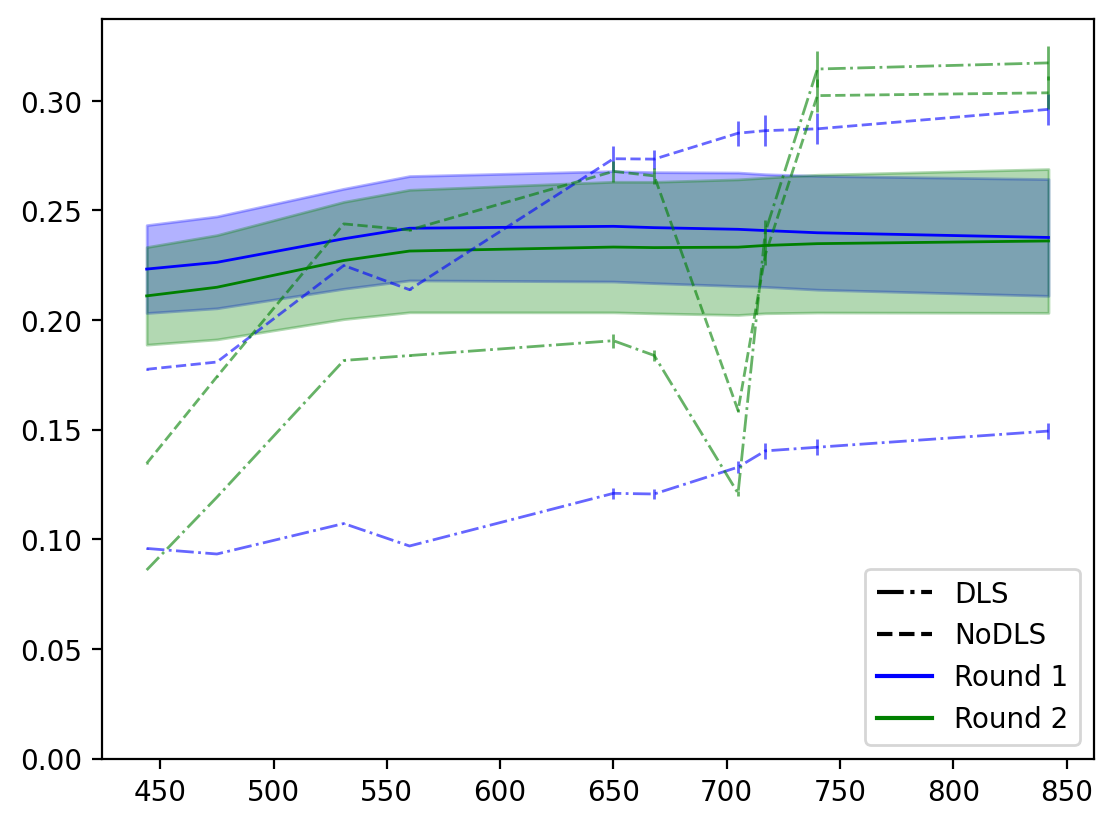

In [138]:
df_all_groundtruth_spectra_stats_10B = df_all_groundtruth_spectra_stats.drop(columns='NDVI740')

fig, ax = plt.subplots()
ROUND_COLORS = {1: 'blue', 2: 'green'}
LINESTYLES = ['-.', '--']
# Associate the linestyles to dls modes
DLS_MODES_LINESTYLES = {dls_mode: LINESTYLES[i] for i, dls_mode in enumerate(DLS_MODES)}

for round_ in [1, 2]:
    y = df_all_groundtruth_spectra_stats_10B.xs("mean", level=1, axis=1).loc[
        ("westham", round_, "grey")
    ]
    x = y.index.to_numpy(dtype=float)
    y = y.to_numpy(dtype=float)
    ystd = df_all_groundtruth_spectra_stats_10B.xs("std", level=1, axis=1).loc[
        ("westham", round_, "grey")
    ].to_numpy(dtype=float)
    ax.plot(x,y,'-', linewidth=1, color=ROUND_COLORS[round_])#, label=f"Round {round_}")
    # Plot the standard deviation shade
    ax.fill_between(x, y+ystd, y-ystd, color=ROUND_COLORS[round_], alpha=0.3)

    geometry = gdf.loc[(round_, 'grey'), "geometry"]

    for dls_mode in DLS_MODES:
        # tarp_spectra = extract_spectra_in_polygon(
        #     raster_path=df_raster_path_in_container.loc[(site, round_, dls_mode), "vsiaz_path"],
        #     geometry=geometry,
        #     band_indexes=SOURCE_BANDS_11B_TO_10B,
        #     wavelengths_nm=MICASENSE_10B_CENTER_WAVELENGTHS,
        # )
        # tarp_spectra_stats = tarp_spectra.agg(["mean", "std"]).T
        # x = tarp_spectra_stats.index.to_numpy(dtype=float)
        # y = tarp_spectra_stats["mean"].to_numpy(dtype=float)
        # y_std = tarp_spectra_stats["std"].to_numpy(dtype=float)
        # ax.errorbar(x, y, yerr=y_std, linestyle=DLS_MODES_LINESTYLES[dls_mode], color=ROUND_COLORS[round_], alpha=0.6, linewidth=2)
        # # ax.plot(x, y, 's--', color=ROUND_COLORS[round_], linewidth=1, label=f"Tarp Round {round_}")

        date_ = ROUND_DATES[round_]
        coeffs_w2b = (
            spatial_coefficients.query(
                "`direction` == 'westham_to_brunswick' and `dls_mode` == @dls_mode and `flight_date` == @date_"
            )
            .set_index("band_name")
            .filter(["gain", "offset"])
            .drop("PAN", axis=0)
            .reset_index(drop=True)
            .set_index(MICASENSE_10B_CENTER_WAVELENGTHS)
        )
        tarp_spectra_corr = (
            tarp_spectra.T.mul(
                coeffs_w2b["gain"],
                axis="index",
            )
            .add(coeffs_w2b["offset"], axis="index")
            .T
        )
        tarp_spectra_corr_stats = tarp_spectra_corr.agg(["mean", "std"]).T
        x = tarp_spectra_corr_stats.index.to_numpy(dtype=float)
        y = tarp_spectra_corr_stats["mean"].to_numpy(dtype=float)
        y_std = tarp_spectra_corr_stats["std"].to_numpy(dtype=float)
        ax.errorbar(x, y, yerr=y_std,
        linestyle=DLS_MODES_LINESTYLES[dls_mode], linewidth=1,
        color=ROUND_COLORS[round_], alpha=0.6)



# Add legend for dls modes
for dls_mode, linestyle in DLS_MODES_LINESTYLES.items():
    ax.plot([], [], linestyle=linestyle, color='black', label=dls_mode)
for round_ in [1, 2]:
    ax.plot([], [], '-', color=ROUND_COLORS[round_], label=f"Round {round_}")

ax.set_ylim(bottom=0)
ax.legend()
